# South Asian Cuisine RAG System

## Overview
This project implements a Retrieval-Augmented Generation (RAG) system for **South Asian cuisine**. It combines:

- **Dense + keyword-based retrieval**
- **Cross-encoder reranking**
- **Prompt-based grounded answer generation using Qwen**
- **Benchmark-based evaluation**
- **Interactive Gradio user interface**


---

## Required Input Files
Make sure the following files are available in the same working directory as the notebook:

- `bge_chunks.pkl`
- `bge_index.faiss`
- `benchmark_dataset.json`



---

## Correct Execution Order

### 1. Retrieval Pipeline
Run the **Retrieval Pipeline** section next.

This section:
- loads `bge_index.faiss`
- loads `bge_chunks.pkl`
- constructs the retrieval pipeline
- performs hybrid retrieval and reranking

This is the section to run before any generation or UI cell.

---

### 2. LLM Prompting and Evaluation
Run the **LLM Prompting and Evaluation** section after retrieval is ready.

This section:
- loads the benchmark dataset
- builds grounded prompts
- runs Qwen-based answer generation
- evaluates prompt strategies
- computes metrics such as:
  - Exact Match
  - Token F1
  - ROUGE-L
  - BERTScore
- saves generation outputs and summary tables

This section uses:

- `benchmark_dataset.json`

---

### 3. Orchestration / UI
Run the **Orchestration / UI** section last.

This section:
- connects retrieval and generation into a user-facing pipeline
- launches the Gradio interface
- allows interactive querying of the system




# 1. REQUIREMENT SETUP

## ⭐ 1.0 Core imports and shared libraries

This cell loads the main Python libraries used throughout the notebook for crawling, preprocessing, chunking, embedding, retrieval, evaluation, and interface development.


In [2]:
!pip install -q numpy pandas matplotlib requests beautifulsoup4 tqdm torch faiss-cpu gradio rank-bm25 sentence-transformers langchain-text-splitters

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.9/515.9 kB 20.1 MB/s eta 0:00:00


In [3]:
# Core imports used across the project

import os
import re
import json
import time
import math
import pickle
import hashlib
import statistics
import unicodedata
from collections import Counter, defaultdict
from difflib import SequenceMatcher
from urllib.parse import urljoin, urlparse, urldefrag, urlunparse

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import torch
import faiss
import gradio as gr

from bs4 import BeautifulSoup
from tqdm import tqdm
from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer, CrossEncoder
from langchain_text_splitters import CharacterTextSplitter, RecursiveCharacterTextSplitter
from sklearn.metrics.pairwise import cosine_similarity

# 2. CORPUS CREATION

## 2.0 Shared corpus helper functions

These helper functions provide reusable utilities for loading, saving, and managing JSON-based corpus files across all sources.


In [4]:
# Common helper functions used across corpus building and later processing

# This function loads a JSON file so saved outputs can be reused in later stages.
def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


# This function saves Python data to JSON in a readable format.
def save_json(data, path):
    directory = os.path.dirname(path)
    if directory:
        os.makedirs(directory, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(data, f, ensure_ascii=False, indent=2)


# This function saves line-delimited JSON for easier downstream processing.
def save_jsonl(data, path):
    directory = os.path.dirname(path)
    if directory:
        os.makedirs(directory, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        for item in data:
            f.write(json.dumps(item, ensure_ascii=False) + "\n")


# This function normalises unicode so multilingual text is handled more consistently.
def normalize_unicode(text: str) -> str:
    return unicodedata.normalize("NFKC", text) if isinstance(text, str) else text


# This function makes web requests safer by retrying when a request fails temporarily.
def safe_get(url, params=None, headers=None, timeout=30, max_retries=6, base_sleep=2.0):
    for attempt in range(max_retries):
        try:
            response = requests.get(url, params=params, headers=headers, timeout=timeout)
            if response.status_code == 429:
                wait_time = base_sleep * (2 ** attempt)
                print(f"Rate limited for {url}. Waiting {wait_time:.1f} seconds.")
                time.sleep(wait_time)
                continue
            response.raise_for_status()
            return response
        except Exception as e:
            wait_time = base_sleep * (2 ** attempt)
            print(f"Request failed for {url}: {e}. Retrying in {wait_time:.1f} seconds.")
            time.sleep(wait_time)
    return None


## 2.1 Wikipedia Corpus

### 2.1.1 Wikipedia article inventory

This cell defines the full set of Wikipedia pages selected for corpus creation, grouped by cuisine families, countries, regions, dishes, and ingredients.


In [5]:
WIKIPEDIA_ARTICLES = [

    # 1) South Asian cuisine overview
    'South_Asian_cuisine', "History_of_Indian_cuisine",

    # 2) Country-level cuisine overviews
    'Indian_cuisine', 'Pakistani_cuisine', 'Bangladeshi_cuisine', 'Sri_Lankan_cuisine', 'Nepali_cuisine', 'Afghan_cuisine', 'Maldivian_cuisine', 'Bhutanese_cuisine', 'Dhivehi_cuisine',

    # 3) Indian regional cuisines - East
    'Bengali_cuisine', 'Cuisine_of_Chhattisgarh', 'Odia_cuisine', 'Bhojpuri_cuisine', 'Jharkhandi_cuisine', 'Maithil_cuisine', 'Bihari_cuisine',

    # 4) Indian regional cuisines - Northeast
    'Assamese_cuisine', 'Arunachalese_cuisine', 'Meghalayan_cuisine', 'Manipuri_cuisine', 'Naga_cuisine', 'Mizo_cuisine', 'Sikkimese_cuisine', 'Tripuri_cuisine', 'Gorkha_cuisine',

    # 5) Indian regional cuisines - North
    'Awadhi_cuisine', 'Cuisine_of_Uttar_Pradesh', 'Himachali_cuisine', 'Kashmiri_cuisine', 'Kumaoni_cuisine', 'Ladakhi_cuisine', 'Mughlai_cuisine', 'Punjabi_cuisine', 'Rajasthani_cuisine',

    # 6) Indian regional cuisines - South
    'Chettinad_cuisine', 'Hyderabadi_cuisine', 'Kerala_cuisine', 'Karnataka_cuisine', 'Tamil_cuisine', 'Telugu_cuisine', 'Thalassery_cuisine', 'Udupi_cuisine',

    # 7) Indian regional cuisines - West
    'Goan_cuisine', 'Gujarati_cuisine', 'Maharashtrian_cuisine', 'Malvani_cuisine', 'Parsi_cuisine', 'Sindhi_cuisine', 'Thathai_Bhatia_cuisine',

    # 8) Other Indian cuisine families / food traditions
    'Indian_Chinese_cuisine', 'Jain_vegetarianism', 'Indian_fast_food',

    # 9) Bangladeshi / Bengali related cuisines and dishes
    'Hilsa', 'Panta_bhat', 'Shorshe_ilish', 'Bhuna_khichuri', 'Mishti_doi', 'Sandesh_(confectionery)', 'Patishapta', 'Muri_(food)', 'Doi_maach', 'Bakarkhani', 'Luchi', 'Porota', 'Bhorta', 'Pitha', 'Ilish',

    # 10) Nepalese and related cuisines
    'Nepali_cuisine', 'Newa_cuisine', 'Tibetan_cuisine', 'Maithil_cuisine', 'Dal_bhat', 'Momo_(food)', 'Thukpa', 'Sel_roti', 'Gundruk', 'Dhido', 'Tongba', 'Chatamari',

    # 11) Pakistani regional cuisines and related dishes
    'Balochi_cuisine', 'Chitrali_cuisine', 'Kalash_cuisine', 'Lahori_cuisine', 'Cuisine_of_Karachi', 'Pashtun_cuisine', 'Saraiki_cuisine', 'Pakistani_Chinese_cuisine', 'Pakistani_fast_food',
    'Nihari', 'Haleem', 'Bihari_kebab', 'Shami_kebab', 'Boti_kebab', 'Karahi', 'Paya_(dish)', 'Sajji', 'Chapli_kebab', 'Mutton_karahi', 'Daal_chawal', 'Siri_paye', 'Qorma', 'Dum_pukht', 'Sohan_halwa', 'Gajar_ka_halwa', 'Sheer_khurma', 'Falooda', 'Rooh_Afza', 'Sindhi_biryani', 'Aloo_paratha',

    # 12) Afghan cuisine and dishes
    'Afghan_cuisine', 'Kabuli_palaw', 'Mantu_(dumpling)', 'Bolani', 'Ashak', 'Shorwa', 'Qabili_palau', 'Afghan_bread', 'Borani_(food)',

    # 13) Maldivian cuisine and dishes
    'Maldivian_cuisine', 'Garudhiya', 'Mas_huni', 'Masroshi', 'Gulha',

    # 14) Bhutanese cuisine and dishes
    'Bhutanese_cuisine', 'Ema_datshi', 'Phaksha_paa', 'Jasha_maru',

    # 15) Sri Lankan cuisine and dishes
    'Sri_Lankan_cuisine', 'Sri_Lankan_curry', 'Hoppers_(food)', 'Kottu', 'Lamprais', 'Pol_sambol', 'Kiribath', 'Watalappan', 'String_hoppers', 'Sri_Lankan_rice_and_curry', 'Pittu',

    # 16) South Indian core dishes and staples
    'Dosa', 'Idli', 'Vada_(food)', 'Upma', 'Uttapam', 'Sambar_(dish)', 'Rasam', 'Pongal_(dish)', 'Appam', 'Idiyappam', 'Medu_vada', 'Neer_dosa', 'Bisi_bele_bath', 'Akki_roti', 'Puttu', 'Avial', 'Poriyal', 'Kootu', 'Kuzhambu', 'Puliyodarai', 'Curd_rice', 'Lemon_rice', 'Coconut_chutney', 'Tomato_chutney', 'Fish_moolie',

    # 17) Indian dishes - curries, mains, breads, snacks
    'Biryani', 'Butter_chicken', 'Palak_paneer', 'Dal_makhani', 'Rogan_josh', 'Korma', 'Vindaloo', 'Tikka_masala', 'Saag', 'Aloo_gobi', 'Chole', 'Rajma', 'Kadhi', 'Matar_paneer', 'Tandoori_chicken', 'Seekh_kebab', 'Kofta', 'Chicken_65', 'Keema', 'Samosa', 'Pakora', 'Pani_puri', 'Bhel_puri', 'Vada_pav', 'Pav_bhaji', 'Chole_bhature', 'Chaat', 'Aloo_tikki', 'Naan', 'Chapati', 'Paratha', 'Puri_(food)', 'Bhatura', 'Kulcha',

    # 18) Desserts, sweets, drinks
    'Gulab_jamun', 'Jalebi', 'Kheer', 'Laddu', 'Rasmalai', 'Kulfi', 'Halwa', 'Barfi', 'Rasgulla', 'Payasam', 'Lassi', 'Masala_chai', 'Chaas', 'Ghevar',

    # 19) Shared South Asian dishes / concepts
    'Curry', 'Dal', 'Pulao', 'Khichdi', 'Kebab', 'Raita',

    # 20) Ingredients, staples, spices, cooking elements
    'Garam_masala', 'Turmeric', 'Cumin', 'Cardamom', 'Coriander', 'Fenugreek', 'Mustard_seed', 'Curry_leaf', 'Asafoetida', 'Ghee', 'Paneer', 'Basmati_rice', 'Tamarind', 'Coconut_milk', 'Chili_pepper', 'Ginger', 'Amchur', 'Chaat_masala', 'Tandoor', 'Rice', 'Roti', 'Atta_flour', 'Bean', 'Black_pepper', 'Clove', 'Yogurt', 'Saffron', 'Tea', 'Barley', 'Eggplant', 'Cucumber', 'Potato', 'Cauliflower',
]

## Wikipedia corpus creation and cleaning

This part builds the **Wikipedia** section of the corpus.


### 2.1.2 Wikipedia seed setup and crawl logs

This cell prepares the deduplicated seed list and initial logging structures used to track accepted and rejected Wikipedia content.


In [6]:
WIKIPEDIA_SEED_ARTICLES = list(dict.fromkeys(WIKIPEDIA_ARTICLES))

# These logs help track what was accepted during the crawl.
accepted_links_log = []
rejected_links_log = []


### 2.1.3 Wikipedia text cleaning and Unicode normalisation

This cell defines the cleaning pipeline used to normalise multilingual text, remove formatting noise, and produce cleaner Wikipedia documents.


In [7]:
# Helper functions for text cleaning

# Unicode cleanup + multilingual-safe normalization

ZERO_WIDTH_PATTERN = r"[\u200B-\u200D\uFEFF]"
CONTROL_CHARS_PATTERN = r"[\x00-\x08\x0B-\x1F\x7F]"

def normalize_unicode(text: str) -> str:
    """
    Normalize Unicode safely while preserving multilingual scripts.
    Removes invisible/control noise but keeps meaningful non-English text.
    """
    text = unicodedata.normalize("NFKC", text)
    text = re.sub(ZERO_WIDTH_PATTERN, "", text)
    text = re.sub(CONTROL_CHARS_PATTERN, "", text)
    return text


def remove_citation_markers(text: str) -> str:
    """Remove Wikipedia-style inline citation markers."""
    text = re.sub(r"\[\d+\]", "", text)
    text = re.sub(
        r"\[(edit|citation needed|note|clarification needed)\]",
        "",
        text,
        flags=re.I
    )
    return text


def remove_parenthetical_noise(text: str) -> str:
    """
    Remove lightweight pronunciation/listen-style parenthetical noise
    while keeping useful cultural/linguistic information.
    """
    text = re.sub(r"\(\s*listen\s*\)", "", text, flags=re.I)
    text = re.sub(r"\(\s*pronounced[^)]*\)", "", text, flags=re.I)
    return text


def remove_boilerplate_lines(text: str) -> str:
    """
    Remove common low-value Wikipedia boilerplate lines.
    """
    patterns = [
        r"^From Wikipedia, the free encyclopedia\s*$",
        r"^Main article:.*$",
        r"^See also:.*$",
        r"^Part of a series on.*$",
        r"^This page was last edited.*$",
        r"^Text is available under the Creative Commons.*$",
        r"^By using this site, you agree.*$",
        r"^Wikipedia® is a registered trademark.*$",
        r"^Wikimedia Foundation\s*$",
        r"^Powered by MediaWiki\s*$",
        r"^Privacy policy.*$",
        r"^About Wikipedia.*$",
        r"^Disclaimers.*$",
        r"^Contact Wikipedia.*$",
        r"^Legal & safety contacts.*$",
        r"^Code of Conduct.*$",
        r"^Developers.*$",
        r"^Statistics.*$",
        r"^Cookie statement.*$",
        r"^Mobile view.*$",
        r"^logo\s*$",
        r"^vte\s*$",
        r"^Portals:\s*$",
    ]
    lines = text.splitlines()
    cleaned_lines = []

    for line in lines:
        stripped = line.strip()
        if any(re.match(p, stripped, flags=re.I) for p in patterns):
            continue
        cleaned_lines.append(line)

    return "\n".join(cleaned_lines)


def remove_trailing_noise_sections(text: str) -> str:
    """
    Remove low-value trailing sections sometimes present in Wikipedia extracts.
    """
    stop_patterns = [
        r"\nReferences\s*\n.*$",
        r"\nExternal links\s*\n.*$",
        r"\nFurther reading\s*\n.*$",
        r"\nNotes\s*\n.*$",
        r"\nBibliography\s*\n.*$",
    ]
    for pattern in stop_patterns:
        text = re.sub(pattern, "", text, flags=re.I | re.S)
    return text


def clean_whitespace(text: str) -> str:
    text = re.sub(r"[ \t]+", " ", text)
    text = re.sub(r"\n\s+\n", "\n\n", text)
    text = re.sub(r"\n{3,}", "\n\n", text)
    return text.strip()


def split_paragraphs(text: str):
    return [p.strip() for p in re.split(r"\n\s*\n", text) if p.strip()]


def remove_duplicate_paragraphs(paragraphs):
    seen = set()
    deduped = []
    for p in paragraphs:
        key = re.sub(r"\s+", " ", p.lower()).strip()
        if key not in seen:
            deduped.append(p)
            seen.add(key)
    return deduped


def remove_duplicate_sentences(paragraph: str) -> str:
    sentences = re.split(r'(?<=[.!?])\s+', paragraph)
    seen = set()
    kept = []
    for sent in sentences:
        key = re.sub(r"\s+", " ", sent.lower()).strip()
        if key and key not in seen:
            kept.append(sent)
            seen.add(key)
    return " ".join(kept).strip()


def filter_short_paragraphs(paragraphs, min_words=8):
    return [p for p in paragraphs if len(p.split()) >= min_words]


def looks_like_caption(paragraph: str) -> bool:
    """
    Remove image-caption.
    """
    p = paragraph.strip()
    if len(p.split()) <= 6 and p.istitle():
        return True
    if re.match(r"^(Photo|Image|Caption|Illustration)\b", p, flags=re.I):
        return True
    return False


def remove_caption_like_paragraphs(paragraphs):
    return [p for p in paragraphs if not looks_like_caption(p)]

def unescape_literal_newlines(text: str) -> str:
    """
    Convert literal escaped newlines/tabs into actual characters.
    Example:
    '\\n' -> newline
    '\\t' -> tab
    """
    if not isinstance(text, str):
        return ""

    text = text.replace("\\n", "\n")
    text = text.replace("\\t", "\t")
    text = text.replace("\\r", "\n")

    return text



def fix_punctuation_spacing(text: str) -> str:
    """
    Fix common scraping artifacts without harming multilingual text.
    """
    # convert braces to parentheses when they behave like inline glosses
    text = re.sub(r"\{\s*([^{}]+?)\s*\}", r"(\1)", text)

    # remove spaces before punctuation
    text = re.sub(r"\s+([,.;:!?])", r"\1", text)

    # add missing space after sentence punctuation when next token starts immediately
    text = re.sub(
        r"([.!?])([A-Za-zÀ-ÿ\u0900-\u097F\u0980-\u09FF\u0A00-\u0A7F\u0B80-\u0BFF\u0D80-\u0DFF])",
        r"\1 \2",
        text
    )

    # collapse repeated punctuation
    text = re.sub(r"\.\.+", ".", text)
    text = re.sub(r",,+", ",", text)

    # small abbreviation repairs
    text = re.sub(r"\bA\.D\.\s+,", "A.D.,", text)
    text = re.sub(r"\bB\.C\.\s+,", "B.C.,", text)

    return text.strip()


# Heading/list residue cleanup

SECTION_HEADING_CANDIDATES = {
    "history", "historic developments", "antiquity", "colonial period",
    "dairy and beverages", "etiquette", "special occasions",
    "regional cuisines", "regional cuisine", "sub-cuisines",
    "east indian cuisines", "west indian cuisines",
    "north indian cuisines", "south indian cuisines",
    "northeast indian cuisines", "fish", "coconuts", "starches", "curries",
    "see also", "references", "notes", "further reading", "external links"
}

def looks_like_heading(line: str) -> bool:
    s = line.strip()
    if not s:
        return False
    if len(s) > 80:
        return False

    if s.lower().rstrip(":") in SECTION_HEADING_CANDIDATES:
        return True

    if re.match(r"^[A-Z][A-Za-z0-9'()/,&\-\s]{1,60}:?$", s):
        words = s.rstrip(":").split()
        if 1 <= len(words) <= 8 and not re.search(r"[.!?]$", s):
            return True

    return False


def remove_heading_only_lines(text: str) -> str:
    """
    Remove isolated section-heading style lines from plaintext extracts.
    """
    lines = text.splitlines()
    kept = []
    for line in lines:
        if looks_like_heading(line):
            continue
        kept.append(line)
    text = "\n".join(kept)
    text = re.sub(r"\n{3,}", "\n\n", text)
    return text.strip()


# Relevance filtering (disambiguation / irrelevant pages)

FOOD_KEYWORDS = {
    "cuisine", "dish", "food", "foods", "ingredient", "ingredients",
    "recipe", "bread", "rice", "curry", "spice", "spices", "meal",
    "dessert", "drink", "beverage", "snack", "cooking", "fried",
    "boiled", "roti", "dal", "lentil", "chutney", "masala"
}

DISAMBIGUATION_SIGNS = [
    "may refer to",
    "can refer to",
    "nickname for",
    "medical slang",
    "fictional character",
    "island of",
    "woreda",
    "prefix meaning",
    "another name for"
]

def is_disambiguation_like(title: str, text: str) -> bool:
    title = (title or "").lower()
    text = (text or "").lower()

    hits = sum(1 for phrase in DISAMBIGUATION_SIGNS if phrase in text)

    lines = [ln.strip() for ln in text.splitlines() if ln.strip()]
    short_lines = [ln for ln in lines if len(ln) < 120]

    if hits >= 2:
        return True

    if len(lines) >= 5 and len(short_lines) / max(len(lines), 1) > 0.7 and hits >= 1:
        return True

    if title == "chole" and "medical slang" in text:
        return True

    return False


def is_cuisine_relevant(title: str, text: str) -> bool:
    """
    Keep cuisine-relevant pages and remove obvious disambiguation/noise pages.
    """
    title_l = (title or "").lower()
    text_l = (text or "").lower()

    if is_disambiguation_like(title, text):
        return False

    if any(k in title_l for k in ["cuisine", "dish", "food"]):
        return True

    keyword_hits = sum(1 for k in FOOD_KEYWORDS if k in text_l)
    return keyword_hits >= 3


# Dedup helpers

def normalize_dedup_key(text: str) -> str:
    text = (text or "").lower().strip()
    text = re.sub(r"\s+", " ", text)
    return text



def split_into_sections(text: str):
    """
    Split very large docs into section-like units using heading lines.
    If no headings are found, returns one intro section.
    """
    lines = text.splitlines()
    sections = []
    current_heading = "intro"
    current_lines = []

    for line in lines:
        stripped = line.strip()
        if looks_like_heading(stripped):
            if current_lines:
                sections.append({
                    "section_title": current_heading,
                    "section_text": "\n".join(current_lines).strip()
                })
            current_heading = stripped.rstrip(":")
            current_lines = []
        else:
            current_lines.append(line)

    if current_lines:
        sections.append({
            "section_title": current_heading,
            "section_text": "\n".join(current_lines).strip()
        })

    sections = [s for s in sections if s["section_text"].strip()]
    if not sections:
        sections = [{"section_title": "intro", "section_text": text.strip()}]

    return sections


def clean_text_advanced(text: str, debug: bool = False) -> str:
    """
    Full Wikipedia cleaning pipeline:
    1. Unicode cleanup
    2. citation cleanup
    3. parenthetical cleanup
    4. boilerplate removal
    5. punctuation/spacing repair
    6. heading/list residue removal
    7. duplicate sentence/paragraph cleanup
    """
    text = unescape_literal_newlines(text)
    text = normalize_unicode(text)
    text = remove_citation_markers(text)
    text = remove_parenthetical_noise(text)
    text = remove_boilerplate_lines(text)
    text = remove_trailing_noise_sections(text)
    text = fix_punctuation_spacing(text)
    text = clean_whitespace(text)
    text = remove_heading_only_lines(text)

    paragraphs = split_paragraphs(text)
    paragraphs = [remove_duplicate_sentences(p) for p in paragraphs]
    paragraphs = remove_duplicate_paragraphs(paragraphs)
    paragraphs = remove_caption_like_paragraphs(paragraphs)
    paragraphs = filter_short_paragraphs(paragraphs, min_words=8)

    cleaned = "\n\n".join(paragraphs)
    cleaned = clean_whitespace(cleaned)


    return cleaned

### 2.1.4 Wikipedia API fetching functions

This cell contains the functions that connect to the Wikipedia API, request article content, and extract structured text for corpus building.


In [8]:
# Functions for fetching Wikipedia content


WIKIPEDIA_API = "https://en.wikipedia.org/w/api.php"
HEADERS = {
    "User-Agent": "COMP64702-RAG-Coursework/1.0 (educational project)"
}

OUTPUT_DIR = "wikipedia_corpus_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)


# This function fetches article content and metadata from Wikipedia.
def fetch_wikipedia_article(title: str):
    """
    Fetch article text and metadata from Wikipedia using the MediaWiki API.
    """
    params = {
        "action": "query",
        "format": "json",
        "titles": title.replace("_", " "),
        "prop": "extracts|info",
        "explaintext": True,
        "exsectionformat": "plain",
        "inprop": "url",
        "redirects": 1
    }

    try:
        response = requests.get(WIKIPEDIA_API, params=params, headers=HEADERS, timeout=20)
        response.raise_for_status()
        data = response.json()

        pages = data.get("query", {}).get("pages", {})
        if not pages:
            return None

        page = next(iter(pages.values()))
        if "missing" in page:
            return None

        return {
            "title": page.get("title", title.replace("_", " ")),
            "url": page.get("fullurl", ""),
            "raw_text": page.get("extract", "")
        }

    except Exception as e:
        print(f"Error fetching {title}: {e}")
        return None

### 2.1.5 Building Wikipedia corpus

This cell combines article fetching and cleaning into a full Wikipedia corpus construction pipeline.


In [9]:
# ============================================================
# STEP 5: BUILD WIKIPEDIA CORPUS
# ============================================================

def build_wikipedia_corpus(article_titles, min_words=50, debug=False, split_large_docs=True):
    corpus = []

    seen_urls = set()
    seen_content_keys = set()

    for article_title in article_titles:
        result = fetch_wikipedia_article(article_title)

        if result is None:
            print(f"Skipped: {article_title}")
            continue

        raw_title = result["title"]
        raw_text = result["raw_text"]
        raw_url = result["url"]


        if not is_cuisine_relevant(raw_title, raw_text):
            print(f"Filtered irrelevant/disambiguation page: {raw_title}")
            continue


        cleaned_text = clean_text_advanced(raw_text, debug=debug)

        if len(cleaned_text.split()) < min_words:
            print(f"Too short after cleaning: {raw_title}")
            continue

        if raw_url and raw_url in seen_urls:
            print(f"Duplicate removed (URL): {raw_title}")
            continue

        content_key = (
            normalize_dedup_key(raw_title),
            normalize_dedup_key(cleaned_text[:3000])
        )
        if content_key in seen_content_keys:
            print(f"Duplicate removed (content): {raw_title}")
            continue

        seen_urls.add(raw_url)
        seen_content_keys.add(content_key)


        if split_large_docs and len(cleaned_text.split()) > 1200:
            sections = split_into_sections(cleaned_text)

            added_any_section = False
            for idx, sec in enumerate(sections):
                sec_text = sec["section_text"]

                if len(sec_text.split()) < min_words:
                    continue

                record = {
                    "title": raw_title,
                    "url": raw_url,
                    "source": "wikipedia",
                    "raw_word_count": len(raw_text.split()),
                    "clean_word_count": len(sec_text.split()),
                    "section_title": sec["section_title"],
                    "doc_type": "section_split",
                    "text": sec_text
                }
                corpus.append(record)
                added_any_section = True

            if added_any_section:
                print(f"Added section-split doc: {raw_title} ({len(sections)} sections)")
                time.sleep(0.5)
                continue

        record = {
            "title": raw_title,
            "url": raw_url,
            "source": "wikipedia",
            "raw_word_count": len(raw_text.split()),
            "clean_word_count": len(cleaned_text.split()),
            "section_title": "full_document",
            "doc_type": "full_document",
            "text": cleaned_text
        }

        corpus.append(record)
        print(f"Added: {raw_title} ({record['clean_word_count']} words)")
        time.sleep(0.5)

    return corpus

### 2.1.6 Wikipedia output saving

This cell defines how the processed Wikipedia corpus is saved for reuse in later notebook stages.


In [10]:
# This function saves the corpus as a JSON file.
def save_corpus_json(corpus, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(corpus, f, ensure_ascii=False, indent=2)


# This function saves the corpus as a JSONL file.
def save_corpus_jsonl(corpus, path):
    with open(path, "w", encoding="utf-8") as f:
        for doc in corpus:
            f.write(json.dumps(doc, ensure_ascii=False) + "\n")


### 2.1.7 Running the Wikipedia pipeline

This cell executes the Wikipedia corpus creation workflow and writes the cleaned outputs to disk.


In [12]:
corpus = build_wikipedia_corpus(
    WIKIPEDIA_ARTICLES,
    min_words=50,
    debug=False,
    split_large_docs=True
)

save_corpus_json(corpus, os.path.join(OUTPUT_DIR, "wikipedia_corpus.json"))
save_corpus_jsonl(corpus, os.path.join(OUTPUT_DIR, "wikipedia_corpus.jsonl"))

print(f"Saved {len(corpus)} Wikipedia documents.")
for doc in corpus[:3]:
    print("\nTitle:", doc["title"])
    print("Source:", doc["source"])
    print("Word count:", doc["clean_word_count"])

Added section-split doc: South Asian cuisine (1 sections)
Added: History of Indian cuisine (1103 words)
Added section-split doc: Indian cuisine (1 sections)
Added section-split doc: Pakistani cuisine (1 sections)
Added section-split doc: Bangladeshi cuisine (1 sections)
Added section-split doc: Sri Lankan cuisine (1 sections)
Added section-split doc: Nepalese cuisine (1 sections)
Added section-split doc: Afghan cuisine (1 sections)
Added: Maldivian cuisine (793 words)
Added: Bhutanese cuisine (545 words)
Duplicate removed (URL): Maldivian cuisine
Added section-split doc: Bengali cuisine (1 sections)
Added: Chhattisgarhi cuisine (363 words)
Added section-split doc: Cuisine of Odisha (1 sections)
Added section-split doc: Bhojpuri cuisine (1 sections)
Added: Jharkhandi cuisine (434 words)
Added: Maithil cuisine (769 words)
Added section-split doc: Bihari cuisine (1 sections)
Added section-split doc: Assamese cuisine (1 sections)
Added: Arunachali cuisine (199 words)
Added: Meghalayan cuis

## Wikibooks corpus creation and cleaning

This part builds the **Wikibooks** section of the corpus.


### 2.2.1 Wikibooks configuration

This cell sets the API endpoints, output paths, and request settings for collecting South Asian cooking content from Wikibooks.


In [13]:
HEADERS = {
    "User-Agent": "COMP64702-RAG-Coursework/2.0 (educational; student project)"
}

WIKIBOOKS_API = "https://en.wikibooks.org/w/api.php"
OUTPUT_DIR = "wikibooks_corpus_outputs"

REQUEST_TIMEOUT = 30
SLEEP_SECONDS = 1.5
CATEGORY_SLEEP_SECONDS = 2.5
MIN_DOC_WORDS = 30
MIN_PARAGRAPH_WORDS = 6
CATEGORY_MAX_DEPTH = 2
MAX_RETRIES = 6
BACKOFF_BASE = 2.0

os.makedirs(OUTPUT_DIR, exist_ok=True)

### 2.2.2 Manually selected Wikibooks pages

This cell defines the seed cookbook pages chosen manually for reliable cuisine-specific coverage.


In [14]:
# Manually selected cookbook pages

WIKIBOOKS_ARTICLES = [
    "Cookbook:Cuisines/South_Asian",
    "Cookbook:Indian_Cuisine",
    "Cookbook:Cuisine_of_India",
    "Cookbook:Biryani",
    "Cookbook:Chicken_Tikka_Masala",
    "Cookbook:Butter_Chicken",
    "Cookbook:Dal",
    "Cookbook:Samosa",
    "Cookbook:Naan",
    "Cookbook:Chapati",
    "Cookbook:Paratha",
    "Cookbook:Dosa",
    "Cookbook:Idli",
    "Cookbook:Palak_Paneer",
    "Cookbook:Aloo_Gobi",
    "Cookbook:Raita",
    "Cookbook:Kheer",
    "Cookbook:Lassi",
    "Cookbook:Masala_Chai",
    "Cookbook:Tandoori_Chicken",
    "Cookbook:Haleem",
    "Cookbook:Pulao",
    "Cookbook:Korma",
    "Cookbook:Gulab_Jamun",
    "Cookbook:Jalebi",
]

### 2.2.3 Category-based Wikibooks discovery

This cell defines the category pages used to discover additional relevant South Asian recipe content automatically.


In [15]:
# Categories used to discover more South Asian pages

SOUTH_ASIAN_CATEGORIES = [
    "Category:South Asian recipes",
    "Category:Afghan recipes",
    "Category:Bengali recipes",
    "Category:Indian recipes",
    "Category:Nepali recipes",
    "Category:Pakistani recipes",
    "Category:Sylheti recipes",
    "Category:Tibetan recipes",
    "Category:Pashtun recipes",
    "Category:Punjabi recipes",
    "Category:Sindhi recipes",
    "Category:Kashmiri recipes",
    "Category:Goan recipes",
    "Category:Tamil recipes",
    "Category:Kerala recipes",
]

### 2.2.4 Wikibooks crawl logs

This cell initialises logging structures for page crawling, category traversal, and failure tracking.


In [16]:
# Logs

crawl_log = []
failed_pages_log = []
category_log = []

### 2.2.5 Wikibooks text cleaning functions

This cell defines the preprocessing logic used to clean and standardise Wikibooks recipe text while preserving useful instructions.


In [17]:
# Helper functions for cleaning Wikibooks text

# This function normalises unicode for more consistent text processing.
def normalize_unicode(text: str) -> str:
    return unicodedata.normalize("NFKC", text)


def remove_citation_markers(text: str) -> str:
    text = re.sub(r"\[\d+\]", "", text)
    text = re.sub(r"\[(edit|citation needed|note|clarification needed)\]", "", text, flags=re.I)
    return text


def remove_pronunciation_noise(text: str) -> str:
    text = re.sub(r"\(\s*listen\s*\)", "", text, flags=re.I)
    text = re.sub(r"\(\s*pronounced[^)]*\)", "", text, flags=re.I)
    return text


def remove_wikibooks_boilerplate_lines(text: str) -> str:
    patterns = [
        r"^From Wikibooks, open books for an open world\s*$",
        r"^Jump to navigation.*$",
        r"^Jump to search.*$",
        r"^Template:.*$",
        r"^Category:.*$",
        r"^Navigation menu\s*$",
        r"^Personal tools\s*$",
        r"^Namespaces\s*$",
        r"^Page actions\s*$",
        r"^Views\s*$",
        r"^Search\s*$",
        r"^Contents\s*$",
        r"^Contents hide\s*$",
        r"^Contents show\s*$",
        r"^This page was last edited.*$",
        r"^Text is available under the Creative Commons.*$",
        r"^By using this site.*$",
        r"^Privacy policy.*$",
        r"^About Wikibooks.*$",
        r"^Disclaimers.*$",
        r"^Code of Conduct.*$",
        r"^Developers.*$",
        r"^Statistics.*$",
        r"^Cookie statement.*$",
        r"^Mobile view.*$",
        r"^Wikimedia Foundation\s*$",
        r"^Powered by MediaWiki\s*$",
        r"^Cookbook \|.*$",
    ]

    lines = text.splitlines()
    cleaned_lines = []

    for line in lines:
        stripped = line.strip()

        if not stripped:
            cleaned_lines.append("")
            continue

        if any(re.match(pattern, stripped, flags=re.I) for pattern in patterns):
            continue

        cleaned_lines.append(line)

    return "\n".join(cleaned_lines)


def clean_whitespace(text: str) -> str:
    text = text.replace("\r", "\n")
    text = re.sub(r"[ \t]+", " ", text)
    text = re.sub(r"\n[ \t]+", "\n", text)
    text = re.sub(r"\n{3,}", "\n\n", text)
    return text.strip()


def remove_trailing_noise_sections(text: str) -> str:
    stop_headers = [
        "References",
        "External links",
        "See also",
        "Notes",
        "Bibliography",
        "Navigation menu",
        "Categories"
    ]

    for header in stop_headers:
        pattern = rf"\n{header}\n.*"
        text = re.sub(pattern, "", text, flags=re.S | re.I)

    return text




def split_paragraphs(text: str):
    return [p.strip() for p in text.split("\n\n") if p.strip()]




def clean_wikibooks_text(text: str, debug: bool = False) -> str:
    text = normalize_unicode(text)
    text = remove_citation_markers(text)
    text = remove_pronunciation_noise(text)
    text = remove_wikibooks_boilerplate_lines(text)
    text = remove_trailing_noise_sections(text)
    text = clean_whitespace(text)

    paragraphs = split_paragraphs(text)


    cleaned = "\n\n".join(paragraphs)
    cleaned = clean_whitespace(cleaned)

    if debug:
        print(cleaned[:3000])

    return cleaned

### 2.2.6 Safe requests with retry and backoff

This cell adds resilient request handling so the crawl can continue even when pages temporarily fail or rate limits occur.


In [18]:
# Helper for safer requests with retry and backoff
# This function sends a web request with retries and backoff.
def safe_get(url, params, headers, timeout=30, max_retries=6, base_sleep=2.0):
    for attempt in range(max_retries):
        try:
            response = requests.get(url, params=params, headers=headers, timeout=timeout)

            if response.status_code == 429:
                wait_time = base_sleep * (2 ** attempt)
                print(f"429 rate limit hit. Sleeping for {wait_time:.1f}s...")
                time.sleep(wait_time)
                continue

            response.raise_for_status()
            return response

        except requests.exceptions.RequestException as e:
            wait_time = base_sleep * (2 ** attempt)

            if attempt == max_retries - 1:
                raise e

            print(f"Request failed ({e}). Retrying in {wait_time:.1f}s...")
            time.sleep(wait_time)

    return None

### 2.2.7 Wikibooks page fetching functions

This cell contains the functions used to retrieve Wikibooks page content and convert it into structured text.


In [19]:
# Functions for fetching Wikibooks pages

# This function fetches one Wikibooks page and its metadata.
def fetch_wikibooks_page(title: str):
    params = {
        "action": "query",
        "format": "json",
        "titles": title,
        "prop": "extracts|info|categories",
        "explaintext": True,
        "exsectionformat": "plain",
        "inprop": "url",
        "cllimit": "max",
        "redirects": 1
    }

    try:
        response = safe_get(
            WIKIBOOKS_API,
            params=params,
            headers=HEADERS,
            timeout=REQUEST_TIMEOUT,
            max_retries=MAX_RETRIES,
            base_sleep=BACKOFF_BASE
        )

        if response is None:
            return None

        data = response.json()
        pages = data.get("query", {}).get("pages", {})
        if not pages:
            return None

        page = next(iter(pages.values()))
        if "missing" in page:
            return None

        return {
            "title": page.get("title", title),
            "url": page.get("fullurl", ""),
            "raw_text": page.get("extract", ""),
            "categories": [x.get("title") for x in page.get("categories", []) if "title" in x]
        }

    except Exception as e:
        failed_pages_log.append({
            "title": title,
            "stage": "fetch_wikibooks_page",
            "error": str(e)
        })
        return None


def get_category_members(category, depth=0, max_depth=CATEGORY_MAX_DEPTH, visited=None):
    if visited is None:
        visited = set()

    if category in visited or depth > max_depth:
        return set()

    visited.add(category)
    all_pages = set()
    cmcontinue = None

    while True:
        params = {
            "action": "query",
            "format": "json",
            "list": "categorymembers",
            "cmtitle": category,
            "cmlimit": 100,
            "cmtype": "page|subcat"
        }

        if cmcontinue:
            params["cmcontinue"] = cmcontinue

        try:
            response = safe_get(
                WIKIBOOKS_API,
                params=params,
                headers=HEADERS,
                timeout=REQUEST_TIMEOUT,
                max_retries=MAX_RETRIES,
                base_sleep=BACKOFF_BASE
            )

            if response is None:
                break

            data = response.json()
            members = data.get("query", {}).get("categorymembers", [])

            for member in members:
                title = member["title"]

                if member["ns"] == 14:
                    subpages = get_category_members(title, depth + 1, max_depth, visited)
                    all_pages.update(subpages)
                else:
                    if title.startswith("Cookbook:"):
                        all_pages.add(title)

            cmcontinue = data.get("continue", {}).get("cmcontinue")
            if not cmcontinue:
                break

            time.sleep(CATEGORY_SLEEP_SECONDS)

        except Exception as e:
            failed_pages_log.append({
                "title": category,
                "stage": "get_category_members",
                "error": str(e)
            })
            break

    return all_pages

### 2.2.8 Combining manual and category-discovered pages

This cell merges directly selected pages with pages discovered through categories to widen the corpus coverage.


In [20]:
# Combining manual titles with category-discovered pages


# This function combines manually chosen pages with category-discovered pages
def collect_manual_and_category_titles():
    manual_titles = set(WIKIBOOKS_ARTICLES)

    category_titles = set()
    for category in tqdm(SOUTH_ASIAN_CATEGORIES, desc="Processing Wikibooks categories"):
        pages = get_category_members(category, depth=0, max_depth=CATEGORY_MAX_DEPTH)
        category_log.append({
            "category": category,
            "pages_found": len(pages)
        })
        category_titles.update(pages)
        time.sleep(1)

    # Keep all Cookbook pages found through the South Asian categories
    filtered_category_titles = {
        title for title in category_titles
        if title.startswith("Cookbook:")
    }

    merged_titles = list(dict.fromkeys(list(manual_titles) + sorted(filtered_category_titles)))

    return merged_titles, manual_titles, category_titles, filtered_category_titles

### 2.2.9 Building structured Wikibooks documents

This cell transforms fetched Wikibooks content into structured document records suitable for later chunking.


In [21]:
# Building structured Wikibooks documents

# This function packages a cleaned Wikibooks page into the standard document format
def make_wikibooks_doc(title, url, raw_text, cleaned_text, categories, scrape_method):
    return {
        "id": None,
        "title": title,
        "url": url,
        "source": "wikibooks",
        "scrape_method": scrape_method,
        "categories": categories,
        "raw_word_count": len(raw_text.split()),
        "clean_word_count": len(cleaned_text.split()),
        "text": cleaned_text
    }

### 2.2.10 Wikibooks corpus creation

This cell assembles the cleaned Wikibooks corpus from all selected and discovered pages.


In [22]:
# Build wikibooks corpus

# This function builds the cleaned Wikibooks corpus
def build_wikibooks_corpus(debug=False):
    merged_titles, manual_titles, category_titles, filtered_category_titles = collect_manual_and_category_titles()

    print(f"Manual Cookbook titles              : {len(manual_titles)}")
    print(f"Raw category-discovered titles      : {len(category_titles)}")
    print(f"Filtered category-matched titles    : {len(filtered_category_titles)}")
    print(f"Final merged Wikibooks page targets : {len(merged_titles)}")

    docs = []

    for title in tqdm(merged_titles, desc="Fetching Wikibooks pages"):
        result = fetch_wikibooks_page(title)

        if result is None:
            crawl_log.append({
                "title": title,
                "status": "missing_or_failed"
            })
            continue

        cleaned_text = clean_wikibooks_text(result["raw_text"], debug=debug)

        if len(cleaned_text.split()) < MIN_DOC_WORDS:
            crawl_log.append({
                "title": result["title"],
                "url": result["url"],
                "status": "rejected_too_short"
            })
            continue

        scrape_method = "manual_seed" if title in manual_titles else "category_discovery"

        doc = make_wikibooks_doc(
            title=result["title"],
            url=result["url"],
            raw_text=result["raw_text"],
            cleaned_text=cleaned_text,
            categories=result["categories"],
            scrape_method=scrape_method
        )

        docs.append(doc)

        crawl_log.append({
            "title": result["title"],
            "url": result["url"],
            "status": "accepted",
            "scrape_method": scrape_method
        })

        time.sleep(SLEEP_SECONDS)

    # No deduplication
    for i, doc in enumerate(docs):
        doc["id"] = f"wikibooks_{i:04d}"

    return docs

### 2.2.11 Saving Wikibooks outputs

This cell saves the processed Wikibooks corpus and related metadata artifacts.


In [23]:
# Saving the cleaned outputs

# This function saves the cleaned Wikibooks outputs and crawl logs.
def save_wikibooks_outputs(final_docs):
    with open(os.path.join(OUTPUT_DIR, "wikibooks_corpus.json"), "w", encoding="utf-8") as f:
        json.dump(final_docs, f, ensure_ascii=False, indent=2)

    with open(os.path.join(OUTPUT_DIR, "wikibooks_crawl_log.json"), "w", encoding="utf-8") as f:
        json.dump(crawl_log, f, ensure_ascii=False, indent=2)

    with open(os.path.join(OUTPUT_DIR, "wikibooks_failed_pages.json"), "w", encoding="utf-8") as f:
        json.dump(failed_pages_log, f, ensure_ascii=False, indent=2)

    with open(os.path.join(OUTPUT_DIR, "wikibooks_category_log.json"), "w", encoding="utf-8") as f:
        json.dump(category_log, f, ensure_ascii=False, indent=2)

    print("Saved Wikibooks outputs.")

### 2.2.12 Running the Wikibooks pipeline

This cell executes the full Wikibooks collection and cleaning workflow.


In [25]:
# This cell runs the Wikibooks pipeline and saves the cleaned outputs.

wikibooks_corpus = build_wikibooks_corpus(debug=False)
save_wikibooks_outputs(wikibooks_corpus)

print(f"Saved {len(wikibooks_corpus)} Wikibooks documents.")

for doc in wikibooks_corpus[:5]:
    print("\nTitle:", doc["title"])
    print("Categories:", doc.get("categories", []))


Processing Wikibooks categories:   0%|          | 0/15 [00:00<?, ?it/s]

429 rate limit hit. Sleeping for 2.0s...
429 rate limit hit. Sleeping for 4.0s...
429 rate limit hit. Sleeping for 8.0s...
429 rate limit hit. Sleeping for 16.0s...
429 rate limit hit. Sleeping for 32.0s...
429 rate limit hit. Sleeping for 64.0s...


Processing Wikibooks categories:   7%|▋         | 1/15 [02:07<29:48, 127.73s/it]

429 rate limit hit. Sleeping for 2.0s...
429 rate limit hit. Sleeping for 4.0s...
429 rate limit hit. Sleeping for 8.0s...
429 rate limit hit. Sleeping for 16.0s...
429 rate limit hit. Sleeping for 32.0s...
429 rate limit hit. Sleeping for 64.0s...


Processing Wikibooks categories:  13%|█▎        | 2/15 [04:14<27:36, 127.39s/it]

...

429 rate limit hit. Sleeping for 2.0s...
429 rate limit hit. Sleeping for 4.0s...
429 rate limit hit. Sleeping for 8.0s...
429 rate limit hit. Sleeping for 16.0s...


Processing Wikibooks categories: 100%|██████████| 15/15 [19:41<00:00, 78.75s/it]


Manual Cookbook titles              : 25
Raw category-discovered titles      : 22
Filtered category-matched titles    : 22
Final merged Wikibooks page targets : 47


Fetching Wikibooks pages: 100%|██████████| 47/47 [01:00<00:00,  1.28s/it]

Saved Wikibooks outputs.
Saved 38 Wikibooks documents.

Title: Cookbook:Masala Chai I
Categories: ['Category:Duplicate recipes', 'Category:Indian recipes', 'Category:Naturally gluten-free recipes', 'Category:Recipes', 'Category:Recipes for chai', 'Category:Recipes using anise', 'Category:Recipes using cardamom', 'Category:Recipes using cinnamon', 'Category:Recipes using clove', 'Category:Recipes using ground ginger', 'Category:Recipes using sugar', 'Category:Recipes using tea', 'Category:Recipes with images', 'Category:Recipes with metric units', 'Category:Recipes without cooking time', 'Category:Recipes without servings', 'Category:Vegetarian recipes', 'Category:Very Easy recipes']

Title: Cookbook:Naan
Categories: ['Category:Afghan recipes', 'Category:Indian recipes', 'Category:Medium Difficulty recipes', 'Category:Pakistani recipes', 'Category:Recipes', 'Category:Recipes for flatbread', 'Category:Recipes using all-purpose flour', 'Category:Recipes using baking soda', 'Category:Recip

## Blog corpus collection and cleaning

This part builds the **blog-based** section of the corpus.


### 2.3.1 Blog source configuration

This cell defines the base blog settings, request parameters, and output locations for the blog corpus.


In [26]:
HEADERS = {
    "User-Agent": "COMP64702-RAG-Coursework/1.0 (educational; student project)"
}

BLOG_BASE_URL = "https://aroundtheworldin80cuisinesblog.wordpress.com/"
OUTPUT_DIR = "blog_corpus_outputs"

REQUEST_TIMEOUT = 30
SLEEP_SECONDS = 1.5
MAX_RETRIES = 6
BACKOFF_BASE = 2.0

os.makedirs(OUTPUT_DIR, exist_ok=True)

### 2.3.2 Blog seed URLs

This cell lists the initial category and archive URLs used to start crawling the food blog source.


In [27]:
# South asian blog seed urls

BLOG_SEED_URLS = [
    urljoin(BLOG_BASE_URL, "category/38-afghanistan/"),
    urljoin(BLOG_BASE_URL, "category/06-northern-india/"),
    urljoin(BLOG_BASE_URL, "category/44-southern-india/"),
    urljoin(BLOG_BASE_URL, "category/54-pakistan/"),
    urljoin(BLOG_BASE_URL, "category/20-sri-lanka-and-the-maldives/"),

    # crucial expansion for Nepal / Bhutan / Bangladesh coverage
    urljoin(BLOG_BASE_URL, "2017/04/27/8-south-asia-minor/"),
]

### 2.3.3 Blog keyword filtering

This cell defines the keyword filters used to keep only blog pages that are relevant to South Asian cuisine.


In [28]:
# Blog keywords

BLOG_SOUTH_ASIAN_KEYWORDS = {
    # regions/cuisines
    "south asian", "indian", "pakistani", "bangladeshi", "bengali",
    "afghan", "afghanistan", "bhutanese", "maldivian", "dhivehi",
    "nepali", "nepalese", "newari", "sri lankan", "tibetan",
    "punjabi", "sindhi", "pashtun", "kashmiri", "goan", "parsi",
    "hyderabadi", "kerala", "tamil", "chettinad", "mughlai",
    "lahori", "balochi", "sylheti",

    # dishes/staples/breads
    "biryani", "pulao", "korma", "haleem", "nihari", "dal",
    "naan", "chapati", "paratha", "dosa", "idli", "sambar",
    "chutney", "raita", "samosa", "pakora", "kebab", "seekh",
    "karahi", "kheer", "jalebi", "gulab jamun", "lassi", "chai",
    "appam", "uttapam", "rasam", "pongal", "pittu", "kiribath",
    "string hoppers", "hoppers", "kottu", "lamprais", "pol sambol",
    "momo", "thukpa", "sel roti", "gundruk", "dhido", "chatamari",
    "ema datshi", "masroshi", "gulha", "garudhiya", "mas huni",
    "kabuli palaw", "bolani", "mantu", "aushak", "shorwa",

    # ingredients/concepts
    "rice", "curry", "paneer", "ghee", "masala", "tandoori",
    "flatbread", "vegetarian", "halal", "street food", "thali"
}

### 2.3.4 Blog crawl logs

This cell initialises logging structures for visited pages, failures, and crawl decisions.


In [29]:
# Logs

crawl_log = []
failed_pages_log = []
accepted_links_log = []
rejected_links_log = []

### 2.3.5 Safe blog requests

This cell adds request retry logic for more reliable blog crawling.


In [30]:
# Safe request helper

# This function sends a web request with retries and backoff.
def safe_get(url, headers=HEADERS, timeout=REQUEST_TIMEOUT, max_retries=MAX_RETRIES, base_sleep=BACKOFF_BASE):
    for attempt in range(max_retries):
        try:
            response = requests.get(url, headers=headers, timeout=timeout)

            if response.status_code == 429:
                wait_time = base_sleep * (2 ** attempt)
                print(f"429 rate limit hit. Sleeping for {wait_time:.1f}s...")
                time.sleep(wait_time)
                continue

            response.raise_for_status()
            return response

        except requests.exceptions.RequestException as e:
            wait_time = base_sleep * (2 ** attempt)

            if attempt == max_retries - 1:
                raise e

            print(f"Request failed ({e}). Retrying in {wait_time:.1f}s...")
            time.sleep(wait_time)

    return None

### 2.3.6 URL and link handling utilities

This cell defines helpers for normalising URLs, extracting links, and managing crawl behaviour.


In [31]:
# Url and link helpers

def normalize_url(url: str) -> str:
    url, _ = urldefrag(url)
    return url.rstrip("/")


def is_blog_url(url: str) -> bool:
    return "aroundtheworldin80cuisinesblog.wordpress.com" in urlparse(url).netloc.lower()


def looks_like_post_or_category(url: str) -> bool:
    path = urlparse(url).path.lower()
    return (
        "/category/" in path
        or re.search(r"/\d{4}/\d{2}/\d{2}/", path) is not None
        or path == "/"
    )


def text_matches_blog_keywords(text: str) -> bool:
    t = text.lower()
    return any(keyword in t for keyword in BLOG_SOUTH_ASIAN_KEYWORDS)

### 2.3.7 Blog cleaning rules

This cell applies specialised cleaning fixes to remove noisy blog artefacts while preserving recipe and cultural content.


In [32]:
# Blog corpus: top cleaning fixes

#  Remove failed share pages and social/footer residue
BLOG_FOOTER_PATTERNS = [
    r"Share on X \(Opens in new window\)",
    r"Share on Facebook \(Opens in new window\)",
    r"Share on Twitter \(Opens in new window\)",
    r"Share on Pinterest \(Opens in new window\)",
    r"Share on Tumblr \(Opens in new window\)",
    r"Share on Reddit \(Opens in new window\)",
    r"Like\s*$",
    r"Loading\.\.\.\s*$",
    r"^\s*X\s*$",
    r"^\s*Facebook\s*$",
]

BAD_SCRAPE_PATTERNS = [
    r"JavaScript is not available",
    r"Please enable JavaScript",
    r"supported browser",
    r"Help Center",
    r"Terms of Service",
    r"Privacy Policy",
    r"Cookie Policy",
    r"©\s*\d{4}\s*X Corp",
    r"x\.com",
]

def is_bad_share_page(title: str, url: str, text: str) -> bool:
    blob = f"{title}\n{url}\n{text}".lower()

    # obvious twitter/x share scrape
    if "?share=twitter" in url.lower():
        return True

    hits = sum(1 for p in BAD_SCRAPE_PATTERNS if re.search(p, blob, flags=re.I))
    return hits >= 2


def strip_social_footer(text: str) -> str:
    """
    Remove WordPress sharing/footer residue from the end of blog posts.
    """
    lines = text.splitlines()
    cleaned = []

    for line in lines:
        stripped = line.strip()

        if any(re.search(p, stripped, flags=re.I) for p in BLOG_FOOTER_PATTERNS):
            continue

        cleaned.append(line)

    text = "\n".join(cleaned)


    text = re.sub(
        r"\nShare on X \(Opens in new window\).*?$",
        "",
        text,
        flags=re.I | re.S
    )
    text = re.sub(
        r"\nShare on Facebook \(Opens in new window\).*?$",
        "",
        text,
        flags=re.I | re.S
    )

    text = re.sub(r"\n{3,}", "\n\n", text)
    return text.strip()


# Canonicalize URLs and deduplicate
def canonicalize_blog_url(url: str) -> str:
    """
    Remove query strings/fragments so share links collapse to one canonical URL.
    """
    if not url:
        return ""

    parsed = urlparse(url)
    clean = parsed._replace(query="", fragment="")
    url = urlunparse(clean)

    # remove trailing slash consistency issues
    url = url.rstrip("/")

    # normalize category vs post URL lightly
    return url.lower()


def normalize_text_key(text: str) -> str:
    text = (text or "").lower().strip()
    text = re.sub(r"\s+", " ", text)
    return text


def is_probable_category_url(url: str) -> bool:
    return "/category/" in (url or "").lower()


# FIX 5: Split broad posts into section-level chunks
def looks_like_blog_heading(line: str) -> bool:
    s = line.strip()
    if not s:
        return False
    if len(s) > 90:
        return False

    # title-like dish/subsection headings
    if re.match(r"^[A-Z][A-Za-z0-9'(),/&\-\s]{2,80}$", s):
        words = s.split()
        # heading-like lines are usually short and not full sentences
        if 1 <= len(words) <= 10 and not re.search(r"[.!?]$", s):
            return True

    return False


def split_blog_into_sections(text: str):
    """
    Split long blog posts using heading-like lines such as dish names.
    """
    lines = text.splitlines()

    sections = []
    current_heading = "intro"
    current_lines = []

    for line in lines:
        stripped = line.strip()

        if looks_like_blog_heading(stripped):
            if current_lines:
                sections.append({
                    "section_title": current_heading,
                    "section_text": "\n".join(current_lines).strip()
                })
            current_heading = stripped
            current_lines = []
        else:
            current_lines.append(line)

    if current_lines:
        sections.append({
            "section_title": current_heading,
            "section_text": "\n".join(current_lines).strip()
        })

    sections = [s for s in sections if s["section_text"].strip()]
    if not sections:
        sections = [{"section_title": "full_document", "section_text": text.strip()}]

    return sections



# This function removes blog-specific noise and keeps the useful content.
def clean_blog_text(text: str) -> str:
    """
    Blog-specific cleaning:
    - keep narrative and cultural content
    - remove share/footer/platform residue
    - normalize whitespace
    """
    if not isinstance(text, str):
        return ""

    text = text.replace("\\n", "\n")
    text = text.replace("\\t", " ")
    text = text.replace("\\r", "\n")

    text = strip_social_footer(text)

    # small artifact cleanup
    text = re.sub(r"\s+([,.;:!?])", r"\1", text)
    text = re.sub(r"[ \t]+", " ", text)
    text = re.sub(r"\n\s+\n", "\n\n", text)
    text = re.sub(r"\n{3,}", "\n\n", text)

    return text.strip()

### 2.3.8 Link extraction and filtering

This cell contains the logic that selects which discovered blog links should be followed or ignored.


In [33]:
# This function extracts crawlable candidate links from a blog page.
def extract_candidate_links(soup: BeautifulSoup, base_url: str):
    links = []

    for a in soup.find_all("a", href=True):
        href = a.get("href", "").strip()
        anchor = a.get_text(" ", strip=True)

        if not href:
            continue

        absolute = normalize_url(urljoin(base_url, href))

        if not is_blog_url(absolute):
            continue

        if not looks_like_post_or_category(absolute):
            continue

        links.append((absolute, anchor))

    # preserve order
    seen = set()
    deduped = []
    for url, anchor in links:
        if url not in seen:
            seen.add(url)
            deduped.append((url, anchor))

    return deduped


def filter_relevant_blog_links(links):
    accepted = []
    rejected = []

    for url, anchor in links:
        combined = f"{url} {anchor}"

        if text_matches_blog_keywords(combined):
            accepted.append({"url": url, "anchor_text": anchor, "reason": "matched_blog_keyword"})
        else:
            rejected.append({"url": url, "anchor_text": anchor, "reason": "no_keyword_match"})

    return accepted, rejected

### 2.3.9 Blog page fetching and parsing

This cell fetches individual blog pages and extracts their main textual content.


In [34]:
# Fetch and parse blog page

# This function downloads and parses one blog page
def fetch_blog_page(url: str):
    try:
        response = safe_get(url)
        if response is None:
            return None

        soup = BeautifulSoup(response.text, "html.parser")

        title_tag = (
            soup.select_one("h1.entry-title")
            or soup.select_one("h2.entry-title")
            or soup.select_one("title")
        )
        title = title_tag.get_text(" ", strip=True) if title_tag else url

        content_container = (
            soup.select_one("div.entry-content")
            or soup.select_one("article")
            or soup.select_one("main")
            or soup
        )

        for bad in content_container.select("script, style, nav, aside, footer, form"):
            bad.decompose()

        text = content_container.get_text("\n", strip=True)
        candidate_links = extract_candidate_links(soup, url)
        accepted_links, rejected_links = filter_relevant_blog_links(candidate_links)

        return {
            "title": title,
            "url": url,
            "raw_text": text,
            "accepted_links": accepted_links,
            "rejected_links": rejected_links
        }

    except Exception as e:
        failed_pages_log.append({
            "url": url,
            "stage": "fetch_blog_page",
            "error": str(e)
        })
        return None

### 2.3.10 Blog JSON helpers and document building

This cell defines helper functions for building structured blog documents and storing them


In [35]:
# This function saves data to JSON
def save_json(data, path):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(data, f, ensure_ascii=False, indent=2)

# This function saves data to JSONL
def save_jsonl(data, path):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        for row in data:
            f.write(json.dumps(row, ensure_ascii=False) + "\n")

# This function loads a JSON file so saved outputs can be reused
def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def make_blog_doc(title, url, raw_text, cleaned_text, doc_id=None):
    return {
        "id": doc_id,
        "title": title,
        "url": url,
        "source": "blog",
        "raw_word_count": len(str(raw_text).split()),
        "clean_word_count": len(str(cleaned_text).split()),
        "section_title": "full_document",
        "doc_type": "full_document",
        "text": cleaned_text
    }

# This function converts raw blog pages into the final cleaned blog corpus.
def build_blog_corpus(raw_blog_docs, min_words=80):
    cleaned_corpus = []

    seen_urls = {}
    seen_texts = set()

    for i, doc in enumerate(raw_blog_docs):
        doc_id = doc.get("id", f"blog_{i}")
        title = doc.get("title", "")
        raw_url = doc.get("url", "")
        raw_text = doc.get("raw_text", doc.get("text", ""))
        source = doc.get("source", "blog")

        if is_bad_share_page(title, raw_url, raw_text):
            print(f"Removed bad share page: {title}")
            continue

        cleaned_text = clean_blog_text(raw_text)

        if len(cleaned_text.split()) < min_words:
            print(f"Too short after cleaning: {title}")
            continue

        canonical_url = canonicalize_blog_url(raw_url)
        text_key = normalize_text_key(cleaned_text[:4000])

        if canonical_url and canonical_url in seen_urls:
            print(f"Duplicate removed (canonical URL): {title}")
            continue

        if text_key in seen_texts:
            print(f"Duplicate removed (same content): {title}")
            continue

        if canonical_url:
            seen_urls[canonical_url] = {
                "title": title,
                "is_category": is_probable_category_url(raw_url)
            }

        seen_texts.add(text_key)

        cleaned_corpus.append({
            "id": doc_id,
            "title": title,
            "url": raw_url,
            "canonical_url": canonical_url,
            "source": source,
            "raw_word_count": len(str(raw_text).split()),
            "clean_word_count": len(str(cleaned_text).split()),
            "section_title": "full_document",
            "doc_type": "full_document",
            "text": cleaned_text
        })

        print(f"Added blog post: {title} ({len(cleaned_text.split())} words)")

    return cleaned_corpus

### 2.3.11 Crawling blog pages from seeds

This cell runs the discovery crawl from the chosen seed URLs.


In [36]:
# Crawl blog pages from seeds

# This function crawls the blog seeds and collects raw blog pages.
def collect_blog_raw_docs(seed_urls, max_pages=60):
    raw_blog_docs = []
    visited = set()
    to_visit = list(seed_urls)

    while to_visit and len(visited) < max_pages:
        url = normalize_url(to_visit.pop(0))

        if not url or url in visited:
            continue

        visited.add(url)
        print(f"[{len(visited)}/{max_pages}] Fetching: {url}")

        page = fetch_blog_page(url)
        if page is None:
            continue

        page["id"] = f"blog_{len(raw_blog_docs)}"
        page["source"] = "blog"
        raw_blog_docs.append(page)

        crawl_log.append({
            "url": url,
            "title": page.get("title", ""),
            "status": "fetched"
        })

        for link in page.get("accepted_links", []):
            next_url = normalize_url(link["url"])
            if next_url and next_url not in visited and next_url not in to_visit:
                to_visit.append(next_url)

        time.sleep(SLEEP_SECONDS)

    return raw_blog_docs

### 2.3.12 Building raw blog documents

This cell creates the first raw document collection from the crawled blog pages.


In [37]:
# Build + save raw blog docs

BLOG_RAW_PATH = os.path.join(OUTPUT_DIR, "blog_raw_docs.json")

raw_blog_docs = collect_blog_raw_docs(BLOG_SEED_URLS, max_pages=60)

save_json(raw_blog_docs, BLOG_RAW_PATH)

print("Saved raw blog docs to:", BLOG_RAW_PATH)
print("Raw blog docs collected:", len(raw_blog_docs))

if raw_blog_docs:
    print("First title:", raw_blog_docs[0]["title"])

[1/60] Fetching: https://aroundtheworldin80cuisinesblog.wordpress.com/category/38-afghanistan
[2/60] Fetching: https://aroundtheworldin80cuisinesblog.wordpress.com/category/06-northern-india
[3/60] Fetching: https://aroundtheworldin80cuisinesblog.wordpress.com/category/44-southern-india
[4/60] Fetching: https://aroundtheworldin80cuisinesblog.wordpress.com/category/54-pakistan
[5/60] Fetching: https://aroundtheworldin80cuisinesblog.wordpress.com/category/20-sri-lanka-and-the-maldives
[6/60] Fetching: https://aroundtheworldin80cuisinesblog.wordpress.com/2017/04/27/8-south-asia-minor
[7/60] Fetching: https://aroundtheworldin80cuisinesblog.wordpress.com/2017/11/05/38-afghanistan
[8/60] Fetching: https://aroundtheworldin80cuisinesblog.wordpress.com/2017/11/05/38-afghanistan/?share=twitter
[9/60] Fetching: https://aroundtheworldin80cuisinesblog.wordpress.com/2017/11/05/38-afghanistan/?share=facebook
Saved raw blog docs to: blog_corpus_outputs/blog_raw_docs.json
Raw blog docs collected: 9
Fir

### 2.3.13 Cleaning and saving the blog corpus

This cell finalises the blog corpus by cleaning, validating, and saving the processed outputs.


In [38]:
# Clean + save blog corpus

BLOG_RAW_PATH = os.path.join(OUTPUT_DIR, "blog_raw_docs.json")
BLOG_CLEAN_JSON = os.path.join(OUTPUT_DIR, "blog_corpus.json")
BLOG_CLEAN_JSONL = os.path.join(OUTPUT_DIR, "blog_corpus.jsonl")

raw_blog_docs = load_json(BLOG_RAW_PATH)

cleaned_blog_corpus = build_blog_corpus(raw_blog_docs, min_words=80)

save_json(cleaned_blog_corpus, BLOG_CLEAN_JSON)
save_jsonl(cleaned_blog_corpus, BLOG_CLEAN_JSONL)

print(f"\nSaved {len(cleaned_blog_corpus)} cleaned blog records.")
for article in cleaned_blog_corpus[:5]:
    print(
        f"- {article['title']} | "
        f"{article.get('section_title', 'full_document')} | "
        f"{article['clean_word_count']} words"
    )

Added blog post: 38. Afghanistan (1453 words)
Added blog post: 6. Northern India (1773 words)
Added blog post: 44. Southern India (1487 words)
Added blog post: 54. Pakistan (1248 words)
Added blog post: 20. Sri Lanka and The Maldives (2535 words)
Added blog post: 8. South Asia Minor (2030 words)
Duplicate removed (same content): 38. Afghanistan
Removed bad share page: https://aroundtheworldin80cuisinesblog.wordpress.com/2017/11/05/38-afghanistan/?share=twitter
Too short after cleaning: Facebook

Saved 6 cleaned blog records.
- 38. Afghanistan | full_document | 1453 words
- 6. Northern India | full_document | 1773 words
- 44. Southern India | full_document | 1487 words
- 54. Pakistan | full_document | 1248 words
- 20. Sri Lanka and The Maldives | full_document | 2535 words


## Corpus Statistics

In [41]:
# ── CORPUS STATISTICS ──────────────────────────────────────────────────────────

# Load all three sub-corpora and combine them
wikipedia_docs = load_json("wikipedia_corpus_outputs/wikipedia_corpus.json")
wikibooks_docs = load_json("wikibooks_corpus_outputs/wikibooks_corpus.json")
blog_docs      = load_json("blog_corpus_outputs/blog_corpus.json")

all_docs = wikipedia_docs + wikibooks_docs + blog_docs

def print_corpus_statistics(docs):
    from collections import defaultdict

    def word_count(doc):
        if "clean_word_count" in doc:
            return doc["clean_word_count"]
        return len(doc.get("text", "").split())

    total_docs  = len(docs)
    word_counts = [word_count(d) for d in docs]
    total_words = sum(word_counts)
    avg_words   = int(total_words / total_docs) if total_docs else 0
    min_words   = min(word_counts) if word_counts else 0
    max_words   = max(word_counts) if word_counts else 0

    source_stats = defaultdict(lambda: {"docs": 0, "words": 0})
    for doc, wc in zip(docs, word_counts):
        src = doc.get("source", "unknown")
        source_stats[src]["docs"]  += 1
        source_stats[src]["words"] += wc

    print("=== CORPUS STATISTICS ===")
    print(f"Total documents : {total_docs}")
    print(f"Total words     : {total_words:,}")
    print(f"Avg words/doc   : {avg_words}")
    print(f"Min words/doc   : {min_words}")
    print(f"Max words/doc   : {max_words}")
    print()

    for src in ["wikipedia", "wikibooks", "blog"]:
        stats = source_stats.get(src)
        if stats:
            print(f"  {src:<12}: {stats['docs']:>3} docs | {stats['words']:>8,} words")

    print()
    print("Sample documents:")
    for i, doc in enumerate(docs[:3]):
        wc      = word_count(doc)
        src     = doc.get("source", "unknown")
        title   = doc.get("title", "Untitled")
        text    = doc.get("text", "")
        preview = " ".join(text.split())[:120]
        print(f"  [doc_{i:04d}] {title} ({src}, {wc} words)")
        print(f"  Preview: {preview}...")
        print()

print_corpus_statistics(all_docs)

=== CORPUS STATISTICS ===
Total documents : 242
Total words     : 275,552
Avg words/doc   : 1138
Min words/doc   : 32
Max words/doc   : 12372

  wikipedia   : 198 docs |  256,620 words
  wikibooks   :  38 docs |    8,406 words
  blog        :   6 docs |   10,526 words

Sample documents:
  [doc_0000] South Asian cuisine (wikipedia, 1230 words)
  Preview: South Asian cuisine includes the traditional cuisines from the modern-day South Asian republics of Bangladesh, India, Ma...

  [doc_0001] History of Indian cuisine (wikipedia, 1103 words)
  Preview: The history of Indian cuisine consists of cuisine of the Indian subcontinent, which is rich and diverse. The diverse cli...

  [doc_0002] Indian cuisine (wikipedia, 12372 words)
  Preview: Indian cuisine consists of a variety of regional and traditional cuisines native to the Indian subcontinent. Given the d...



# 3. CHUNKING

Once the cleaned corpus is ready, the full documents are converted into retrieval-ready chunks.

Three strategies are compared here:

- fixed-size chunking  
- recursive chunking  
- adaptive source-aware chunking  

The goal is to decide which strategy gives the best balance between context quality and retrieval usefulness.


## 3.1 Chunking Dependencies

This cell installs or prepares the text-splitting tools required for chunking experiments.


In [45]:
# Install this once if the text splitter package is not already available.

!pip install -q langchain-text-splitters


## 3.2 Chunking Library Imports

This cell imports the specific splitter classes used by the chunking strategies.


In [46]:
from langchain_text_splitters import (
    CharacterTextSplitter,
    RecursiveCharacterTextSplitter
)

## 3.3 Loading the Unified Corpus

This cell loads the cleaned corpus that will be transformed into retrieval-ready chunks.


In [47]:
# Load corpus

# This function loads a JSON file so saved outputs can be reused.
def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

wikipedia_docs = load_json("wikipedia_corpus_outputs/wikipedia_corpus.json")
wikibooks_docs = load_json("wikibooks_corpus_outputs/wikibooks_corpus.json")
blog_docs = load_json("blog_corpus_outputs/blog_corpus.json")

all_docs = wikipedia_docs + wikibooks_docs + blog_docs

print("Wikipedia docs:", len(wikipedia_docs))
print("Wikibooks docs:", len(wikibooks_docs))
print("Blog docs:", len(blog_docs))
print("Total docs:", len(all_docs))
with open("all_docs.json", "w", encoding="utf-8") as f:
    json.dump(all_docs, f, ensure_ascii=False, indent=2)

Wikipedia docs: 198
Wikibooks docs: 38
Blog docs: 6
Total docs: 242


## 3.4 Standardising Documents Across Sources

This cell converts documents from Wikipedia, Wikibooks, and blogs into a consistent internal format.


In [2]:
# Standardize documents
with open("all_docs.json", "r", encoding="utf-8") as f:
    all_docs = json.load(f)

# This function maps each source document into one shared schema.
def standardize_doc(doc):
    return {
        "title": doc.get("title", ""),
        "url": doc.get("url", ""),
        "source": doc.get("source", ""),
        "text": doc.get("text", "")
    }

all_docs = [standardize_doc(doc) for doc in all_docs]

## 3.5 Chunk Schema

This cell defines the structure used to represent each chunk and its metadata.


In [8]:
# Chunk record helper

# This function creates one chunk record with the metadata needed later.
def make_chunk(doc, chunk_text, chunk_index, method, section_title="", min_words=20):
    """
    Create one chunk record with metadata.
    Reject tiny chunks.
    """
    chunk_text = chunk_text.strip()

    if len(chunk_text.split()) < min_words:
        return None

    return {
        "chunk_id": f"{doc['source']}_{chunk_index}_{method}",
        "doc_title": doc.get("title", ""),
        "doc_url": doc.get("url", ""),
        "source": doc.get("source", ""),
        "chunk_index": chunk_index,
        "chunking_method": method,
        "section_title": section_title if section_title is not None else "",
        "word_count": len(chunk_text.split()),
        "text": chunk_text
    }

## 3.6 Different Chunking Strategies

### 3.6.1 Fixed-Size Chunking Strategy

This cell implements the baseline fixed-size chunking method.


In [9]:
# Strategy 1 - fixed-size chunking

fixed_splitter = CharacterTextSplitter(
    separator=" ",
    chunk_size=1200,
    chunk_overlap=250
)

def chunk_document_fixed(doc):
    chunks = fixed_splitter.split_text(doc["text"])

    records = []
    for i, chunk_text in enumerate(chunks):
        chunk = make_chunk(
            doc=doc,
            chunk_text=chunk_text,
            chunk_index=i,
            method="fixed_size",
            min_words=30
        )
        if chunk is not None:
            records.append(chunk)

    return records

### 3.6.2 Recursive Chunking Strategy

This cell implements recursive chunking to respect text boundaries more naturally.


In [10]:
# Strategy 2 - recursive chunking

recursive_splitter = RecursiveCharacterTextSplitter(
    separators=["\n\n", "\n", ". ", " ", ""],
    chunk_size=1400,
    chunk_overlap=250
)

def chunk_document_recursive(doc):
    chunks = recursive_splitter.split_text(doc["text"])

    records = []
    for i, chunk_text in enumerate(chunks):
        chunk = make_chunk(
            doc=doc,
            chunk_text=chunk_text,
            chunk_index=i,
            method="recursive",
            min_words=40
        )
        if chunk is not None:
            records.append(chunk)

    return records

### 3.6.3 Adaptive source-aware chunking strategy

This cell implements the source-aware adaptive chunking logic tailored to different document types.


In [11]:
# Strategy 3 - adaptive source-aware chunking

# Wikipedia: larger chunks, long structured pages
wiki_splitter = RecursiveCharacterTextSplitter(
    separators=["\n\n", "\n", ". ", " ", ""],
    chunk_size=1500,
    chunk_overlap=250
)

# Wikibooks: smaller recipe pages
wikibooks_splitter = RecursiveCharacterTextSplitter(
    separators=["\n\n", "\n", ". ", " ", ""],
    chunk_size=900,
    chunk_overlap=120
)

# Blog: medium-sized narrative chunks
blog_splitter = RecursiveCharacterTextSplitter(
    separators=["\n\n", "\n", ". ", " ", ""],
    chunk_size=1200,
    chunk_overlap=180
)

def chunk_document_adaptive(doc):
    source = doc.get("source", "").lower()

    if source == "wikipedia":
        splitter = wiki_splitter
        method = "adaptive_wikipedia"
        min_words = 45

    elif source == "wikibooks":
        splitter = wikibooks_splitter
        method = "adaptive_wikibooks"
        min_words = 20

    elif source == "blog":
        splitter = blog_splitter
        method = "adaptive_blog"
        min_words = 35

    else:
        splitter = recursive_splitter
        method = "adaptive_default"
        min_words = 30

    chunks = splitter.split_text(doc["text"])

    records = []
    for i, chunk_text in enumerate(chunks):
        chunk = make_chunk(
            doc=doc,
            chunk_text=chunk_text,
            chunk_index=i,
            method=method,
            min_words=min_words
        )
        if chunk is not None:
            records.append(chunk)

    return records

## 3.7 Context enrichment

This cell enriches chunks with metadata and surrounding context to improve retrieval usefulness.


In [12]:
# This function adds lightweight contextual metadata to each chunk.
def enrich_chunk(chunk):
    text = chunk["text"].lower()

    country_terms = [
        "india", "pakistan", "bangladesh", "nepal",
        "bhutan", "afghanistan", "maldives", "sri lanka"
    ]

    matched_countries = [c for c in country_terms if c in text]

    chunk["metadata"] = {
        "matched_countries": matched_countries
    }

    return chunk

## 3.8 Running chunking experiments

This cell executes the chunking strategies and generates candidate chunk datasets.


In [13]:
# This function applies the selected chunking strategy to the corpus.
def chunk_corpus(docs, strategy="fixed"):
    all_chunks = []

    for doc in docs:
        if strategy == "fixed":
            chunks = chunk_document_fixed(doc)

        elif strategy == "recursive":
            chunks = chunk_document_recursive(doc)

        elif strategy == "adaptive":
            chunks = chunk_document_adaptive(doc)

        else:
            raise ValueError(f"Unknown strategy: {strategy}")

        chunks = [enrich_chunk(c) for c in chunks]
        all_chunks.extend(chunks)

    return all_chunks


fixed_chunks = chunk_corpus(all_docs, strategy="fixed")
recursive_chunks = chunk_corpus(all_docs, strategy="recursive")
adaptive_chunks = chunk_corpus(all_docs, strategy="adaptive")

print("Fixed chunks:", len(fixed_chunks))
print("Recursive chunks:", len(recursive_chunks))
print("Adaptive chunks:", len(adaptive_chunks))

Fixed chunks: 2224
Recursive chunks: 2122
Adaptive chunks: 2142


## 3.9 Saving chunk files

This cell saves the produced chunk outputs for later embedding and evaluation.


In [14]:
# Save chunk files

# This function saves data to JSON.
def save_json(data, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(data, f, ensure_ascii=False, indent=2)

save_json(fixed_chunks, "chunks_fixed.json")
save_json(recursive_chunks, "chunks_recursive.json")
save_json(adaptive_chunks, "chunks_adaptive.json")

print("Saved chunk files.")

Saved chunk files.


## 3.10 Comparing chunking strategies

This cell compares the produced chunk sets across the different chunking methods.


In [15]:
# Compare chunking strategies

# This function summarises chunking outputs so strategies can be compared.
def summarize_chunks(chunks, strategy_name):
    word_lengths = [c["word_count"] for c in chunks]
    by_source = Counter(c["source"] for c in chunks)

    return {
        "strategy": strategy_name,
        "num_chunks": len(chunks),
        "avg_words_per_chunk": round(statistics.mean(word_lengths), 2) if word_lengths else 0,
        "median_words_per_chunk": round(statistics.median(word_lengths), 2) if word_lengths else 0,
        "min_words": min(word_lengths) if word_lengths else 0,
        "max_words": max(word_lengths) if word_lengths else 0,
        "chunks_by_source": dict(by_source)
    }

comparison = [
    summarize_chunks(fixed_chunks, "fixed"),
    summarize_chunks(recursive_chunks, "recursive"),
    summarize_chunks(adaptive_chunks, "adaptive")
]

for row in comparison:
    print("=" * 70)
    print("Strategy:", row["strategy"])
    print("Number of chunks:", row["num_chunks"])
    print("Average words/chunk:", row["avg_words_per_chunk"])
    print("Median words/chunk:", row["median_words_per_chunk"])
    print("Min words:", row["min_words"])
    print("Max words:", row["max_words"])
    print("Chunks by source:", row["chunks_by_source"])

Strategy: fixed
Number of chunks: 2224
Average words/chunk: 181.47
Median words/chunk: 193.0
Min words: 31
Max words: 239
Chunks by source: {'wikipedia': 1805, 'wikibooks': 352, 'blog': 67}
Strategy: recursive
Number of chunks: 2122
Average words/chunk: 161.72
Median words/chunk: 175.0
Min words: 41
Max words: 268
Chunks by source: {'wikipedia': 1731, 'wikibooks': 324, 'blog': 67}
Strategy: adaptive
Number of chunks: 2142
Average words/chunk: 158.87
Median words/chunk: 159.0
Min words: 22
Max words: 273
Chunks by source: {'wikipedia': 1599, 'wikibooks': 471, 'blog': 72}


## 3.11 Chunking evaluation

This section evaluates the chunking strategies using coursework-relevant quality indicators. The purpose is to justify the final chunking choice in a clear and evidence-based way.


### 3.11.1 Chunking Evaluation Metrics

This cell defines the evaluation functions used to compare chunk quality across strategies.


In [16]:
import json
import re
import random
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from sentence_transformers import SentenceTransformer


CORPUS_PATH = "all_docs.json"

CHUNK_FILES = {
    "fixed": "chunks_fixed.json",
    "recursive": "chunks_recursive.json",
    "adaptive": "chunks_adaptive.json"
}

EMBED_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"

RANDOM_SEED = 42
MAX_CHUNKS_FOR_SEMANTIC = 1200
NEGATIVE_SENTENCES_PER_CHUNK = 4

COLORS = {
    "fixed": "#81A6C6",
    "recursive": "#A2CB8B",
    "adaptive": "#BDA6CE"
}

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# load data
def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def norm_text(text):
    return re.sub(r"\s+", " ", str(text).strip()).lower()

def tokenize(text):
    return re.findall(r"\b[\w'-]+\b", norm_text(text))

def sentence_split(text):
    text = str(text).strip()
    if not text:
        return []
    parts = re.split(r"(?<=[.!?])\s+|\n{2,}", text)
    parts = [p.strip() for p in parts if len(tokenize(p)) >= 4]
    return parts

def to_unit_interval(cos_val):
    # convert cosine similarity from [-1, 1] to [0, 1]
    return (cos_val + 1.0) / 2.0

def doc_key_from_doc(doc):
    url = str(doc.get("url", "")).strip()
    source = norm_text(doc.get("source", ""))
    title = norm_text(doc.get("title", ""))
    if url:
        return f"url::{url}"
    return f"{source}|||{title}"

def doc_key_from_chunk(chunk):
    url = str(chunk.get("doc_url", "")).strip()
    source = norm_text(chunk.get("source", ""))
    title = norm_text(chunk.get("doc_title", ""))
    if url:
        return f"url::{url}"
    return f"{source}|||{title}"


all_docs = load_json(CORPUS_PATH)
chunk_sets = {name: load_json(path) for name, path in CHUNK_FILES.items()}

print("Loaded docs:", len(all_docs))
for name, chunks in chunk_sets.items():
    print(f"{name}: {len(chunks)} chunks")

doc_map = {doc_key_from_doc(doc): doc for doc in all_docs}

chunks_by_strategy_by_doc = {}
for strategy, chunks in chunk_sets.items():
    grouped = defaultdict(list)
    for chunk in chunks:
        grouped[doc_key_from_chunk(chunk)].append(chunk)

    for key in grouped:
        grouped[key] = sorted(grouped[key], key=lambda x: x.get("chunk_index", 0))

    chunks_by_strategy_by_doc[strategy] = grouped

# align chunks to original doc
def locate_chunk_spans_in_doc(doc_text, ordered_chunks, backtrack=500):
    spans = []
    cursor = 0

    for chunk in ordered_chunks:
        chunk_text = str(chunk.get("text", ""))
        if not chunk_text:
            spans.append(None)
            continue

        start_search = max(0, cursor - backtrack)
        idx = doc_text.find(chunk_text, start_search)

        if idx == -1:
            idx = doc_text.find(chunk_text)

        if idx == -1:
            spans.append(None)
            continue

        span = (idx, idx + len(chunk_text))
        spans.append(span)
        cursor = span[1]

    return spans

chunk_spans = {}
for strategy, grouped in chunks_by_strategy_by_doc.items():
    chunk_spans[strategy] = {}
    resolved = 0
    total = 0

    for key, ordered_chunks in tqdm(grouped.items(), desc=f"Aligning spans: {strategy}"):
        doc = doc_map.get(key)
        if doc is None:
            spans = [None] * len(ordered_chunks)
        else:
            spans = locate_chunk_spans_in_doc(str(doc.get("text", "")), ordered_chunks)

        chunk_spans[strategy][key] = spans
        resolved += sum(1 for s in spans if s is not None)
        total += len(spans)

    print(f"{strategy} span resolution rate: {resolved / max(total, 1):.4f}")

# BOUNDARY INTEGRITY
def previous_non_space(text, pos):
    i = pos - 1
    while i >= 0 and text[i].isspace():
        i -= 1
    return text[i] if i >= 0 else ""

def next_non_space(text, pos):
    i = pos
    while i < len(text) and text[i].isspace():
        i += 1
    return text[i] if i < len(text) else ""

def boundary_integrity_for_doc(doc_text, ordered_chunks, spans):
    start_scores = []
    end_scores = []

    for chunk, span in zip(ordered_chunks, spans):
        chunk_text = str(chunk.get("text", "")).strip()
        if not chunk_text:
            continue

        if span is not None:
            start, end = span

            prev_char = previous_non_space(doc_text, start)
            next_char = next_non_space(doc_text, end)
            end_last_char = previous_non_space(doc_text, end)

            start_ok = (
                start == 0
                or prev_char in ".!?\n:;•"
            )

            end_ok = (
                end >= len(doc_text)
                or end_last_char in ".!?\n:;•"
                or next_char in "•"
            )

            start_scores.append(1.0 if start_ok else 0.0)
            end_scores.append(1.0 if end_ok else 0.0)

        else:
            first_char = chunk_text[0]
            last_char = chunk_text[-1]

            start_ok = first_char.isupper() or first_char.isdigit()
            end_ok = last_char in ".!?:;"

            start_scores.append(1.0 if start_ok else 0.0)
            end_scores.append(1.0 if end_ok else 0.0)

    if not start_scores:
        return 0.0

    return 0.5 * np.mean(start_scores) + 0.5 * np.mean(end_scores)

def evaluate_boundary_integrity(strategy):
    grouped = chunks_by_strategy_by_doc[strategy]
    scores = []
    weights = []

    for key, ordered_chunks in grouped.items():
        doc = doc_map.get(key)
        if doc is None:
            continue

        spans = chunk_spans[strategy][key]
        score = boundary_integrity_for_doc(str(doc.get("text", "")), ordered_chunks, spans)

        scores.append(score)
        weights.append(len(ordered_chunks))

    return float(np.average(scores, weights=weights)) if scores else 0.0


semantic_model = SentenceTransformer(EMBED_MODEL_NAME)

doc_sentence_pool = {}
for key, doc in tqdm(doc_map.items(), desc="Preparing doc sentence pools"):
    sents = sentence_split(doc.get("text", ""))
    # deduplicate while preserving order
    seen = set()
    unique_sents = []
    for s in sents:
        ns = norm_text(s)
        if ns not in seen:
            unique_sents.append(s)
            seen.add(ns)
    doc_sentence_pool[key] = unique_sents

# semantic coherence
def sample_chunks(chunks, max_chunks):
    if len(chunks) <= max_chunks:
        return chunks
    idx = np.random.choice(len(chunks), size=max_chunks, replace=False)
    idx = sorted(idx.tolist())
    return [chunks[i] for i in idx]

def evaluate_semantic_coherence(strategy):
    all_chunks = sample_chunks(chunk_sets[strategy], MAX_CHUNKS_FOR_SEMANTIC)

    records = []
    sentence_texts = set()

    for chunk in all_chunks:
        doc_key = doc_key_from_chunk(chunk)
        chunk_text = chunk.get("text", "")
        chunk_sents = sentence_split(chunk_text)

        if len(chunk_sents) < 2:
            continue

        chunk_sent_norms = {norm_text(s) for s in chunk_sents}
        candidate_negatives = [
            s for s in doc_sentence_pool.get(doc_key, [])
            if norm_text(s) not in chunk_sent_norms
        ]

        if len(candidate_negatives) > NEGATIVE_SENTENCES_PER_CHUNK:
            negatives = random.sample(candidate_negatives, NEGATIVE_SENTENCES_PER_CHUNK)
        else:
            negatives = candidate_negatives

        record = {
            "chunk_sents": chunk_sents,
            "negatives": negatives
        }
        records.append(record)

        for s in chunk_sents:
            sentence_texts.add(s)
        for s in negatives:
            sentence_texts.add(s)

    if not records:
        return 0.0

    sentence_texts = list(sentence_texts)
    sent_emb = semantic_model.encode(
        sentence_texts,
        batch_size=64,
        show_progress_bar=False,
        convert_to_numpy=True,
        normalize_embeddings=True
    )
    sent_to_emb = {s: sent_emb[i] for i, s in enumerate(sentence_texts)}

    chunk_scores = []
    chunk_weights = []

    for record in records:
        chunk_sents = record["chunk_sents"]
        negatives = record["negatives"]

        sent_vecs = np.vstack([sent_to_emb[s] for s in chunk_sents])

        # A. Adjacent sentence similarity
        adj_sims = []
        for a, b in zip(sent_vecs[:-1], sent_vecs[1:]):
            adj_sims.append(to_unit_interval(float(np.dot(a, b))))
        adj_score = float(np.mean(adj_sims)) if adj_sims else 0.0

        # B. Topic focus: sentence similarity to chunk centroid
        centroid = sent_vecs.mean(axis=0)
        centroid_norm = np.linalg.norm(centroid)
        if centroid_norm > 0:
            centroid = centroid / centroid_norm
            focus_sims = [to_unit_interval(float(np.dot(v, centroid))) for v in sent_vecs]
            focus_score = float(np.mean(focus_sims))
        else:
            focus_score = 0.0

        # C. Local coherence margin against same-document negatives
        if negatives:
            neg_vecs = np.vstack([sent_to_emb[s] for s in negatives])
            bg_sims = []
            for v in sent_vecs:
                sims = neg_vecs @ v
                bg_sims.append(float(np.mean([to_unit_interval(x) for x in sims])))
            bg_score = float(np.mean(bg_sims))
        else:
            bg_score = adj_score  # neutral fallback

        local_margin = adj_score - bg_score
        margin_score = np.clip((local_margin + 1.0) / 2.0, 0.0, 1.0)

        # Final stronger semantic coherence
        score = (
            0.45 * adj_score +
            0.35 * focus_score +
            0.20 * margin_score
        )

        chunk_scores.append(score)
        chunk_weights.append(len(chunk_sents))

    return float(np.average(chunk_scores, weights=chunk_weights)) if chunk_scores else 0.0

# REDUNDANCY EFFICIENCY
def overlap_words_from_spans(doc_text, span_a, span_b):
    start = max(span_a[0], span_b[0])
    end = min(span_a[1], span_b[1])
    if end <= start:
        return 0
    overlap_text = doc_text[start:end]
    return len(tokenize(overlap_text))

def chunk_word_count(chunk):
    return int(chunk.get("word_count", len(tokenize(chunk.get("text", "")))))

def evaluate_redundancy_efficiency(strategy):
    grouped = chunks_by_strategy_by_doc[strategy]
    overlap_ratios = []
    weights = []

    for key, ordered_chunks in grouped.items():
        doc = doc_map.get(key)
        if doc is None:
            continue

        doc_text = str(doc.get("text", ""))
        spans = chunk_spans[strategy][key]

        if len(ordered_chunks) < 2:
            continue

        for chunk_a, chunk_b, span_a, span_b in zip(
            ordered_chunks[:-1], ordered_chunks[1:], spans[:-1], spans[1:]
        ):
            if span_a is None or span_b is None:
                continue

            words_a = max(chunk_word_count(chunk_a), 1)
            words_b = max(chunk_word_count(chunk_b), 1)

            overlap_words = overlap_words_from_spans(doc_text, span_a, span_b)

            # ratio relative to shorter chunk
            overlap_ratio = overlap_words / max(min(words_a, words_b), 1)

            overlap_ratios.append(overlap_ratio)
            weights.append((words_a + words_b) / 2)

    if not overlap_ratios:
        return 1.0

    mean_overlap = float(np.average(overlap_ratios, weights=weights))
    efficiency = 1.0 - mean_overlap
    return float(np.clip(efficiency, 0.0, 1.0))

# run evaluation
rows = []

for strategy in ["fixed", "recursive", "adaptive"]:
    print(f"\nEvaluating: {strategy}")

    boundary = evaluate_boundary_integrity(strategy)
    semantic = evaluate_semantic_coherence(strategy)
    redundancy = evaluate_redundancy_efficiency(strategy)

    rows.append({
        "strategy": strategy,
        "boundary_integrity": boundary,
        "semantic_coherence": semantic,
        "redundancy_efficiency": redundancy
    })

results_df = pd.DataFrame(rows)

# order nicely
strategy_order = ["fixed", "recursive", "adaptive"]
results_df["strategy"] = pd.Categorical(results_df["strategy"], categories=strategy_order, ordered=True)
results_df = results_df.sort_values("strategy").reset_index(drop=True)

print("\nREVISED CHUNKING METRICS")
display(results_df.round(6))

results_df.to_csv("chunking_metrics_presentation_revised.csv", index=False)


Loaded docs: 411
fixed: 2224 chunks
recursive: 2122 chunks
adaptive: 2142 chunks


Aligning spans: fixed: 100%|██████████| 403/403 [00:00<00:00, 19792.10it/s]


fixed span resolution rate: 1.0000


Aligning spans: recursive: 100%|██████████| 399/399 [00:00<00:00, 19050.48it/s]


recursive span resolution rate: 1.0000


...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Preparing doc sentence pools: 100%|██████████| 403/403 [00:00<00:00, 869.75it/s]



Evaluating: fixed

Evaluating: recursive

Evaluating: adaptive

REVISED CHUNKING METRICS


,strategy,boundary_integrity,semantic_coherence,redundancy_efficiency
0,fixed,0.231790,0.707317,0.751694
1,recursive,0.759425,0.715498,0.913654
2,adaptive,0.766807,0.716945,0.929524


### 3.11.2 Chunking Evaluation Visualisation

This cell visualises the chunking evaluation results for easier comparison.


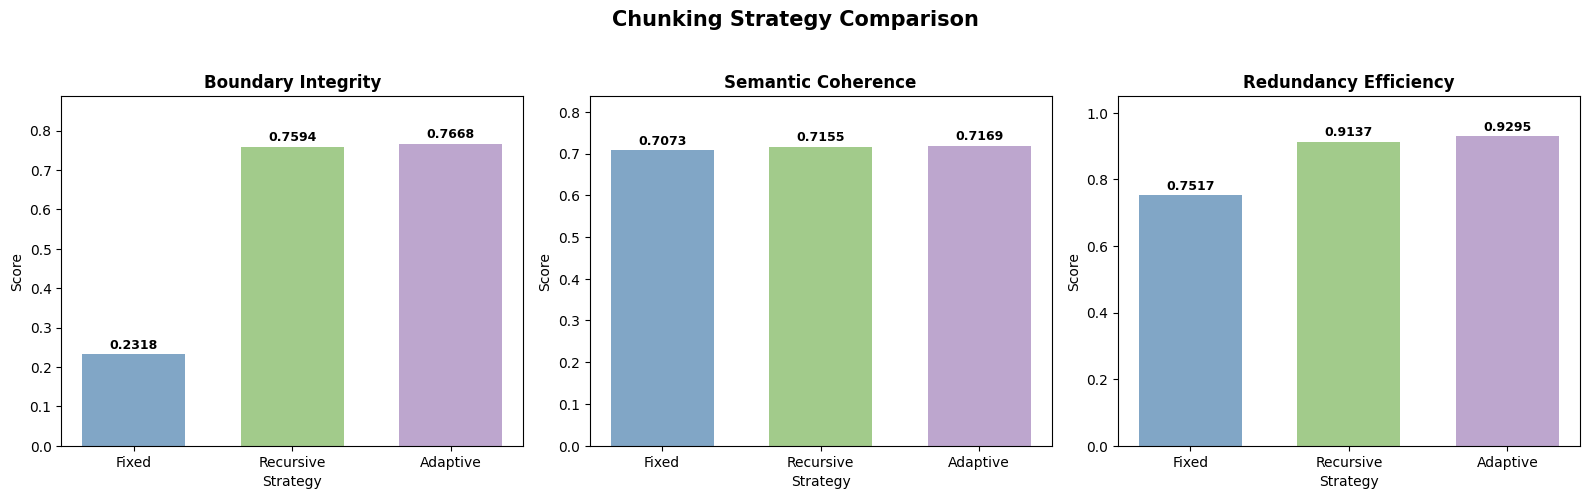

In [17]:
metric_map = {
    "boundary_integrity": "Boundary Integrity",
    "semantic_coherence": "Semantic Coherence",
    "redundancy_efficiency": "Redundancy Efficiency"
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
fig.suptitle(
    "Chunking Strategy Comparison",
    fontsize=15,
    fontweight="bold",
    y=1.03
)

for ax, (metric_key, metric_title) in zip(axes, metric_map.items()):
    x = np.arange(len(results_df))
    y = results_df[metric_key].values
    colors = [COLORS[s] for s in results_df["strategy"]]

    bars = ax.bar(x, y, color=colors, width=0.65)

    ax.set_xticks(x)
    ax.set_xticklabels([s.capitalize() for s in results_df["strategy"]], fontsize=10)
    ax.set_title(metric_title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Strategy", fontsize=10)
    ax.set_ylabel("Score", fontsize=10)
    ax.set_ylim(0, min(1.05, max(y) + 0.12))

    for bar, val in zip(bars, y):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            val + 0.008,
            f"{val:.4f}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold"
        )


plt.tight_layout()
plt.show()

### 3.11.3 Saving Chunking Evaluation Results

This cell saves the chunking evaluation outputs for reporting and reuse.


In [18]:
# Save results

results_df.to_csv("chunking_evaluation_results.csv", index=False)
print("Saved results to chunking_evaluation_results.csv")

Saved results to chunking_evaluation_results.csv


# 4. Embedding generation

This section turns the final adaptive chunks into dense vector representations using three embedding models:

1. **sentence-transformers/all-MiniLM-L6-v2**  
2. **BAAI/bge-large-en-v1.5**  
3. **intfloat/multilingual-e5-large**

The goal is to compare an efficient baseline with stronger large-model alternatives before choosing the best setup for retrieval.


## 4.1 Loading Final Adaptive Chunks

This cell loads the final chunk set chosen for embedding generation.


In [ ]:
# This function loads a JSON file so saved outputs can be reused.
def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

adaptive_chunks = load_json("chunks_adaptive.json")

print("Total adaptive chunks:", len(adaptive_chunks))
print("Sample keys:", adaptive_chunks[0].keys())

## 4.2 Preparing Text for Embedding

This cell prepares and formats chunk text so it can be passed correctly into the embedding models.


In [ ]:
# Prepare texts for embedding

chunk_texts = [doc["text"].strip() for doc in adaptive_chunks if doc.get("text", "").strip()]

print("Usable chunk texts:", len(chunk_texts))
print("\nSample chunk:\n")
print(chunk_texts[0][:500])

## 4.3 Embedding Dependencies

This cell installs the packages required for embedding generation.


In [ ]:
# Install these packages once if they are not already available.

!pip install -q "transformers==4.44.2" "sentence-transformers==3.0.1" "tokenizers<0.20"


## 4.4 Comparing different embedding models

### 4.4.1 Model 1: all-MiniLM-L6-v2

This cell generates embeddings using the MiniLM baseline model.


In [ ]:

print('\n=== MODEL 1: all-MiniLM-L6-v2 ===')
print(f'Total chunks to embed: {len(chunk_texts):,}')
print('Batch size: 64')
print('Starting model load...')

model_minilm = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

print('Model loaded successfully.')
print('Starting embedding generation...')

start = time.time()
embeddings_minilm = model_minilm.encode(
    chunk_texts,
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True
)
elapsed = time.time() - start

np.savez_compressed('embeddings_minilm_adaptive.npz', embeddings=embeddings_minilm)

print('\nFinished MiniLM embedding generation.')
print(f'Shape: {embeddings_minilm.shape}')
print(f'Time taken: {elapsed:.1f} seconds')
print('Saved: embeddings_minilm_adaptive.npz')

### 4.4.2 Model 2: BAAI/bge-large-en-v1.5

This cell generates embeddings using the BGE large model.


In [ ]:
# MODEL 2 — BAAI/bge-large-en-v1.5
print('\n=== MODEL 2: BAAI/bge-large-en-v1.5 ===')
print('(Large model — first run may take a few minutes)')
model_bge = SentenceTransformer('BAAI/bge-large-en-v1.5')

start = time.time()
embeddings_bge = model_bge.encode(
    chunk_texts,
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True
)
elapsed = time.time() - start

np.savez_compressed('embeddings_bge_adaptive.npz', embeddings=embeddings_bge)

print(f'Adaptive | chunks: {len(chunk_texts):>5,} | dims: {embeddings_bge.shape[1]:>6,} | time: {elapsed:.1f}s | saved: embeddings_bge_adaptive.npz')

### 4.4.3 Model 3: intfloat/multilingual-e5-large

This cell generates embeddings using the multilingual E5 model.


In [ ]:
# MODEL 3 — intfloat/multilingual-e5-large
print('\nMODEL 3: intfloat/multilingual-e5-large\n')
print('(Large multilingual model — first run may take a few minutes)')
model_e5 = SentenceTransformer('intfloat/multilingual-e5-large')

e5_passages = [f"passage: {text}" for text in chunk_texts]

start = time.time()
embeddings_e5 = model_e5.encode(
    e5_passages,
    batch_size=32,
    show_progress_bar=True,
    normalize_embeddings=True
)
elapsed = time.time() - start

np.savez_compressed('embeddings_e5_adaptive.npz', embeddings=embeddings_e5)

print(f'Adaptive | chunks: {len(chunk_texts):>5,} | dims: {embeddings_e5.shape[1]:>6,} | time: {elapsed:.1f}s | saved: embeddings_e5_adaptive.npz')

## 4.5 Embedding evaluation with benchmark queries

This stage evaluates each embedding model against the benchmark dataset.


### 4.5.1 Benchmark-Based Embedding Evaluation

This cell evaluates embedding models against benchmark queries using retrieval-focused similarity metrics.


In [ ]:
# Fast cosine-similarity evaluation pipeline
# Benchmark-grounded version
#
# Metrics:
#   - Hit@K
#   - Precision@K
#   - Recall@K
#   - Reciprocal Rank (RR)
#   - MRR
#   - DCG@K
#   - nDCG@K
#   - MAP@K

!pip install -q sentence-transformers scikit-learn pandas numpy matplotlib tqdm


# Paths
BENCHMARK_PATH = "benchmark_dataset.json"
CHUNKS_PATH = "chunks_adaptive.json"

MODEL_CONFIGS = {
    "MiniLM": {
        "embedding_file": "embeddings_minilm_adaptive.npz",
        "query_model_name": "sentence-transformers/all-MiniLM-L6-v2",
        "query_prefix": ""
    },

    "BGE": {
        "embedding_file": "embeddings_bge_adaptive.npz",
        "query_model_name": "BAAI/bge-large-en-v1.5",
        "query_prefix": "Represent this sentence for searching relevant passages: "
    },

    "E5": {
        "embedding_file": "embeddings_e5_adaptive.npz",
        "query_model_name": "intfloat/multilingual-e5-large",
        "query_prefix": "query: "
    }
}

TOP_K_RETRIEVAL = 10
K_VALUES = [1, 3, 5]

# Helpers
# This function loads a JSON file so saved outputs can be reused.
def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def normalize_text(text):
    if text is None:
        return ""
    text = str(text).lower().strip()
    text = re.sub(r"\s+", " ", text)
    return text

def tokenize(text):
    return re.findall(r"[a-zA-Z0-9]+", normalize_text(text))

def keyword_overlap_ratio(gold_answer, chunk_text):
    gold_tokens = set(tokenize(gold_answer))
    chunk_tokens = set(tokenize(chunk_text))
    if not gold_tokens:
        return 0.0
    return len(gold_tokens & chunk_tokens) / len(gold_tokens)

def safe_text(chunk):
    for key in ["text", "chunk_text", "content", "body", "passage"]:
        if key in chunk and isinstance(chunk[key], str):
            return chunk[key]
    return ""

def canonicalize_title(text):
    text = normalize_text(text)
    text = text.replace("â€™", "'").replace("’", "'")
    text = re.sub(r"\s+", " ", text).strip()

    # remove subtitle/bracket variants only at the end for matching robustness
    text = re.sub(r"\s*\([^)]*\)\s*$", "", text).strip()

    return text

def safe_title(chunk):
    for key in ["doc_title", "source_title", "title", "article_title", "page_title"]:
        val = chunk.get(key)
        if isinstance(val, str) and val.strip():
            return canonicalize_title(val)
    return ""

def safe_source(chunk):
    raw = normalize_text(chunk.get("source", ""))
    if raw in ["wp", "wikipedia.org"]:
        return "wikipedia"
    if raw in ["wikibook", "wikibooks.org"]:
        return "wikibooks"
    if raw in ["wordpress", "blogs"]:
        return "blog"
    return raw

def l2_normalize(arr):
    arr = np.asarray(arr, dtype=np.float32)
    if arr.ndim == 1:
        arr = arr.reshape(1, -1)
    norms = np.linalg.norm(arr, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    return arr / norms

def load_embeddings(npz_path):
    data = np.load(npz_path, allow_pickle=True)
    for key in ["embeddings", "array", "chunk_embeddings"]:
        if key in data:
            print(f"Using key '{key}' from {npz_path}")
            return np.asarray(data[key], dtype=np.float32)
    first_key = list(data.keys())[0]
    print(f"Using fallback key '{first_key}' from {npz_path}")
    return np.asarray(data[first_key], dtype=np.float32)

def top_k_indices_desc(scores, k):
    k = min(k, len(scores))
    idx = np.argpartition(scores, -k)[-k:]
    idx = idx[np.argsort(scores[idx])[::-1]]
    return idx

# Metric functions
def precision_at_k(rels, k):
    rels = np.asarray(rels[:k], dtype=np.float32)
    if len(rels) == 0:
        return 0.0
    return float(np.sum(rels > 0) / len(rels))

def recall_at_k(rels, total_relevant, k):
    if total_relevant == 0:
        return 0.0
    rels = np.asarray(rels[:k], dtype=np.float32)
    return float(np.sum(rels > 0) / total_relevant)

def hit_at_k(rels, k):
    return float(np.any(np.asarray(rels[:k]) > 0))

def reciprocal_rank(rels):
    rels = np.asarray(rels)
    hits = np.where(rels > 0)[0]
    if len(hits) == 0:
        return 0.0
    return float(1.0 / (hits[0] + 1))

def average_precision_at_k(rels, total_relevant, k):
    if total_relevant == 0:
        return 0.0
    rels = np.asarray(rels[:k])
    precisions = []
    hit_count = 0
    for i, rel in enumerate(rels, start=1):
        if rel > 0:
            hit_count += 1
            precisions.append(hit_count / i)
    if len(precisions) == 0:
        return 0.0
    return float(np.sum(precisions) / min(total_relevant, k))

def dcg_at_k(graded_rels, k):
    graded_rels = np.asarray(graded_rels[:k], dtype=np.float32)
    if len(graded_rels) == 0:
        return 0.0
    discounts = np.log2(np.arange(2, len(graded_rels) + 2))
    return float(np.sum(graded_rels / discounts))

def ndcg_at_k(graded_rels, ideal_graded_rels, k):
    dcg = dcg_at_k(graded_rels, k)
    idcg = dcg_at_k(sorted(ideal_graded_rels, reverse=True), k)
    if idcg == 0:
        return 0.0
    return float(dcg / idcg)

# Load data
benchmark_data = load_json(BENCHMARK_PATH)
chunks_data = load_json(CHUNKS_PATH)

benchmark = benchmark_data["results"] if isinstance(benchmark_data, dict) and "results" in benchmark_data else benchmark_data
chunks = chunks_data["chunks"] if isinstance(chunks_data, dict) and "chunks" in chunks_data else chunks_data

print("Benchmark size:", len(benchmark))
print("Chunks size:", len(chunks))

chunk_texts = [safe_text(c) for c in chunks]
chunk_titles = [safe_title(c) for c in chunks]
chunk_sources = [safe_source(c) for c in chunks]

# Build benchmark-grounded qrels
# qrels[query_id] = {chunk_id: graded_relevance}
#
# relevance grades:
#   3 = exact source_title + source match and strong answer overlap
#   2 = exact source_title + source match and moderate answer overlap
#   1 = exact source_title + source match only
def build_qrels_fast():
    qrels = {}

    for q_idx, item in enumerate(tqdm(benchmark, desc="Building qrels")):
        query_id = str(item.get("query_id", q_idx))
        gold_title = canonicalize_title(item.get("source_title", ""))
        gold_source = normalize_text(item.get("source", ""))
        gold_answer = item.get("response", "")

        qrels[query_id] = {}

        for c_idx, chunk in enumerate(chunks):
            chunk_title = chunk_titles[c_idx]
            chunk_source = chunk_sources[c_idx]

            # source must match first
            if chunk_source != gold_source:
                continue

            exact_title_match = (chunk_title == gold_title)
            contains_match = (
                gold_title and chunk_title and
                (gold_title in chunk_title or chunk_title in gold_title)
            )

            # relevant if exact title match OR close title containment
            if not (exact_title_match or contains_match):
                continue

            overlap = keyword_overlap_ratio(gold_answer, chunk_texts[c_idx])

            if exact_title_match and overlap >= 0.20:
                score = 3
            elif contains_match and overlap >= 0.10:
                score = 2
            else:
                score = 1

            qrels[query_id][str(c_idx)] = score

    return qrels

print("\nBuilding benchmark-grounded qrels once...")
qrels = build_qrels_fast()

# Optional sanity check
relevant_counts = [sum(1 for v in q.values() if v > 0) for q in qrels.values()]
print("Avg relevant chunks per query:", round(float(np.mean(relevant_counts)), 2))
print("Min relevant chunks per query:", int(np.min(relevant_counts)))
print("Max relevant chunks per query:", int(np.max(relevant_counts)))

# Evaluate one model
def evaluate_model_fast(model_name, embedding_file, query_model_name, query_prefix=""):
    print(f"\n{'='*70}")
    print(f"Evaluating {model_name}")
    print(f"{'='*70}")

    chunk_embs = load_embeddings(embedding_file)
    chunk_embs = l2_normalize(chunk_embs)

    if chunk_embs.shape[0] != len(chunks):
        raise ValueError(
            f"{model_name}: embeddings rows ({chunk_embs.shape[0]}) do not match chunks ({len(chunks)})."
        )

    retrieval_model = SentenceTransformer(query_model_name)

    query_texts = []
    for item in benchmark:
        q = item["query"]
        if query_prefix:
            q = query_prefix + q
        query_texts.append(q)

    query_embs = retrieval_model.encode(
        query_texts,
        batch_size=32,
        show_progress_bar=True,
        normalize_embeddings=True
    ).astype(np.float32)

    sim_matrix = cosine_similarity(query_embs, chunk_embs)

    per_query_rows = []

    for q_idx, item in enumerate(tqdm(benchmark, desc=f"Ranking {model_name}")):
        query_id = str(item.get("query_id", q_idx))
        sims = sim_matrix[q_idx]
        ranked_idx = top_k_indices_desc(sims, TOP_K_RETRIEVAL)

        graded_lookup = qrels.get(query_id, {})
        ranked_graded_rels = [graded_lookup.get(str(i), 0) for i in ranked_idx]
        ranked_binary_rels = [1 if r > 0 else 0 for r in ranked_graded_rels]

        total_relevant = sum(1 for v in graded_lookup.values() if v > 0)
        ideal_graded_rels = list(graded_lookup.values())

        row = {
            "model": model_name,
            "query_id": query_id,
            "query": item["query"],
            "question_type": item.get("question_type", "unknown"),
            "gold_source_title": item.get("source_title", ""),
            "gold_source": item.get("source", ""),
            "top1_chunk_id": int(ranked_idx[0]),
            "top1_score": float(sims[ranked_idx[0]]),
            "top1_title": chunk_titles[ranked_idx[0]],
            "top1_source": chunk_sources[ranked_idx[0]],
            "top1_preview": chunk_texts[ranked_idx[0]][:250].replace("\n", " "),
            "RR": reciprocal_rank(ranked_binary_rels),
            "MRR": reciprocal_rank(ranked_binary_rels),
            "MAP@5": average_precision_at_k(ranked_binary_rels, total_relevant, 5),
            "DCG@5": dcg_at_k(ranked_graded_rels, 5),
            "nDCG@5": ndcg_at_k(ranked_graded_rels, ideal_graded_rels, 5),
        }

        for k in K_VALUES:
            row[f"Hit@{k}"] = hit_at_k(ranked_binary_rels, k)
            row[f"Precision@{k}"] = precision_at_k(ranked_binary_rels, k)
            row[f"Recall@{k}"] = recall_at_k(ranked_binary_rels, total_relevant, k)

        per_query_rows.append(row)

    return pd.DataFrame(per_query_rows)

# Run active models
all_results = []

for model_name, cfg in MODEL_CONFIGS.items():
    if not os.path.exists(cfg["embedding_file"]):
        print(f"Skipping {model_name}: file not found -> {cfg['embedding_file']}")
        continue

    model_df = evaluate_model_fast(
        model_name=model_name,
        embedding_file=cfg["embedding_file"],
        query_model_name=cfg["query_model_name"],
        query_prefix=cfg["query_prefix"]
    )
    all_results.append(model_df)

if len(all_results) == 0:
    raise FileNotFoundError("No active embedding files found.")

results_df = pd.concat(all_results, ignore_index=True)

# Overall summary
summary_df = results_df.groupby("model").agg({
    "Hit@1": "mean",
    "Hit@3": "mean",
    "Hit@5": "mean",
    "Precision@1": "mean",
    "Precision@3": "mean",
    "Precision@5": "mean",
    "Recall@1": "mean",
    "Recall@3": "mean",
    "Recall@5": "mean",
    "RR": "mean",
    "MRR": "mean",
    "MAP@5": "mean",
    "DCG@5": "mean",
    "nDCG@5": "mean"
}).reset_index()

summary_df["CompositeScore"] = (
    0.30 * summary_df["Recall@5"] +
    0.20 * summary_df["MRR"] +
    0.20 * summary_df["nDCG@5"] +
    0.15 * summary_df["Precision@5"] +
    0.15 * summary_df["Hit@5"]
)

summary_df = summary_df.sort_values(
    by=["CompositeScore", "Recall@5", "MRR", "nDCG@5"],
    ascending=False
)

print("\nOVERALL RESULTS")
print(summary_df.round(4))

summary_df.to_csv("evaluation_summary_models.csv", index=False)
results_df.to_csv("evaluation_detailed_per_query.csv", index=False)

# Per question type
type_summary = results_df.groupby(["model", "question_type"]).agg({
    "Hit@5": "mean",
    "Precision@5": "mean",
    "Recall@5": "mean",
    "MRR": "mean",
    "MAP@5": "mean",
    "DCG@5": "mean",
    "nDCG@5": "mean"
}).reset_index()

print("\nPER QUESTION TYPE")
print(type_summary.round(4))

type_summary.to_csv("evaluation_by_question_type.csv", index=False)

# Per source
source_summary = results_df.groupby(["model", "gold_source"]).agg({
    "Hit@5": "mean",
    "Precision@5": "mean",
    "Recall@5": "mean",
    "MRR": "mean",
    "MAP@5": "mean",
    "DCG@5": "mean",
    "nDCG@5": "mean"
}).reset_index()

print("\nPER SOURCE")
print(source_summary.round(4))

source_summary.to_csv("evaluation_by_source.csv", index=False)

# Error analysis
print("\nERROR ANALYSIS")

for model_name in results_df["model"].unique():
    print(f"\n--- {model_name}: failures where Hit@5 = 0 ---")
    failures = results_df[
        (results_df["model"] == model_name) &
        (results_df["Hit@5"] == 0)
    ].copy()

    failures = failures.sort_values(by="top1_score", ascending=False)

    if len(failures) == 0:
        print("No failures at top-5.")
        continue

    cols = [
        "query_id", "query", "question_type",
        "gold_source_title", "gold_source",
        "top1_title", "top1_source", "top1_score"
    ]
    print(failures[cols].head(5).to_string(index=False))

# Plots
for metric in ["Recall@5", "MRR", "DCG@5", "nDCG@5", "Hit@5"]:
    plt.figure(figsize=(8, 5))
    plt.bar(summary_df["model"], summary_df[metric])
    plt.title(f"{metric} by Model")
    plt.ylabel(metric)
    plt.tight_layout()
    plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load the full results
summary_df = pd.read_csv('evaluation_summary_models.csv')

# 1. Define ALL the metrics you want to see
metrics_to_plot = ["Hit@1", "Hit@5", "MRR", "MAP@5", "nDCG@5", "Recall@5", "Precision@5"]
metric_labels = ["Hit@1", "Hit@5", "MRR", "MAP@5", "nDCG@5", "Recall@5", "Prec@5"]

# 2. Prepare Data
plot_df = summary_df.reset_index() if 'model' not in summary_df.columns else summary_df
df_melted = plot_df.melt(id_vars="model", value_vars=metrics_to_plot,
                         var_name="Metric", value_name="Score")

# 3. Visualization
plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")
custom_palette = ["#427AB5", "#9AD872", "#BDA6CE"]

ax = sns.barplot(data=df_melted, x="Metric", y="Score", hue="model", palette=custom_palette)

# Add numeric labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=9)

plt.title("Core Retrieval Performance: Model Comparison", fontsize=16, fontweight='bold', pad=20)
plt.ylabel("Score (0.0 - 1.0)", fontsize=12)
plt.xlabel("Evaluation Metric", fontsize=12)
plt.ylim(0, 1.15) # Room for labels

# Improve Legend
plt.legend(title="Embedding Model", loc='upper right', frameon=True, shadow=True, ncol=3)

plt.tight_layout()
plt.savefig('comprehensive_model_comparison.png', dpi=300)
plt.show()

# 5.Vector database construction

This section builds the vector index used for semantic retrieval.


## 5.1 FAISS Installation and Setup

In [ ]:
# Install FAISS once if it is not already available.

!pip install -q faiss-cpu


## 5.2 Loading Chunks and Embeddings into FAISS

This cell loads the saved chunks and embedding matrices, then prepares the vector index artifacts.


In [ ]:
CHUNKS_PATH = "chunks_adaptive.json"
EMBEDDINGS_PATH = "embeddings_bge_adaptive.npz"

# load chunks
with open(CHUNKS_PATH, "r", encoding="utf-8") as f:
    chunks_data = json.load(f)

chunks = chunks_data["chunks"] if isinstance(chunks_data, dict) and "chunks" in chunks_data else chunks_data

# load embeddings
data = np.load(EMBEDDINGS_PATH, allow_pickle=True)
if "embeddings" in data:
    embeddings = data["embeddings"]
else:
    embeddings = data[list(data.keys())[0]]

embeddings = embeddings.astype("float32")

print("Chunks:", len(chunks))
print("Embeddings shape:", embeddings.shape)

if len(chunks) != embeddings.shape[0]:
    raise ValueError("Number of chunks and embeddings do not match.")

# normalize for cosine similarity
faiss.normalize_L2(embeddings)

# create FAISS index
dimension = embeddings.shape[1]
index = faiss.IndexFlatIP(dimension)   # inner product on normalized vectors = cosine similarity
index.add(embeddings)

# save index
faiss.write_index(index, "bge_index.faiss")

# save chunk metadata
with open("bge_chunks.pkl", "wb") as f:
    pickle.dump(chunks, f)

print("FAISS index saved as bge_index.faiss")
print("Chunk metadata saved as bge_chunks.pkl")

# 6. Retrieval pipeline

This section implements the main retrieval logic used by the final RAG system.


## ⭐ 6.1 Retrieval Pipeline Implementation

This cell defines the retrieval workflow that combines query processing, hybrid search, filtering, and reranking.


In [4]:
# Flow:
#   -> query cleaning
#   -> hybrid retrieval (dense + BM25)
#   -> noisy/duplicate filtering
#   -> cross-encoder reranking
#   -> final top chunks

!pip install -q faiss-cpu sentence-transformers rank-bm25



# 1. load files and models
FAISS_INDEX_PATH = "bge_index.faiss"
CHUNKS_PATH = "bge_chunks.pkl"

EMBED_MODEL_NAME = "BAAI/bge-large-en-v1.5"
CROSS_ENCODER_MODEL_NAME = "cross-encoder/ms-marco-MiniLM-L-6-v2"

index = faiss.read_index(FAISS_INDEX_PATH)

with open(CHUNKS_PATH, "rb") as f:
    chunks = pickle.load(f)

embed_model = SentenceTransformer(EMBED_MODEL_NAME)
cross_encoder = CrossEncoder(CROSS_ENCODER_MODEL_NAME)

print("FAISS vectors:", index.ntotal)
print("Chunks loaded:", len(chunks))

# 2. helpers
def clean_text(text):
    text = str(text).strip().lower()
    text = re.sub(r"\s+", " ", text)
    return text

def tokenize(text):
    return re.findall(r"\b\w+\b", clean_text(text))

def get_chunk_text(chunk):
    for key in ["text", "chunk_text", "content", "body", "passage"]:
        if key in chunk and isinstance(chunk[key], str):
            return chunk[key]
    return ""

def get_chunk_title(chunk):
    for key in ["doc_title", "source_title", "title", "article_title", "page_title"]:
        if key in chunk and isinstance(chunk[key], str):
            return chunk[key]
    return ""

def get_chunk_source(chunk):
    return chunk.get("source", "")

# 3. prepare bm25
chunk_texts = [get_chunk_text(c) for c in chunks]
tokenized_corpus = [tokenize(text) for text in chunk_texts]
bm25 = BM25Okapi(tokenized_corpus)

# 4. dense retrieval
def retrieve_dense(query, top_k=10):
    query_for_dense = "Represent this sentence for searching relevant passages: " + query
    query_emb = embed_model.encode([query_for_dense]).astype("float32")
    faiss.normalize_L2(query_emb)

    scores, indices = index.search(query_emb, top_k)

    results = []
    for rank, idx in enumerate(indices[0], start=1):
        if idx == -1:
            continue

        chunk = chunks[idx]
        results.append({
            "chunk_id": int(idx),
            "dense_score": float(scores[0][rank - 1]),
            "bm25_score": 0.0,
            "source": get_chunk_source(chunk),
            "source_title": get_chunk_title(chunk),
            "text": get_chunk_text(chunk)
        })
    return results

# 5. bm25 retrieval
def retrieve_bm25(query, top_k=10):
    query_tokens = tokenize(query)
    scores = bm25.get_scores(query_tokens)
    top_indices = np.argsort(scores)[::-1][:top_k]

    results = []
    for idx in top_indices:
        chunk = chunks[idx]
        results.append({
            "chunk_id": int(idx),
            "dense_score": 0.0,
            "bm25_score": float(scores[idx]),
            "source": get_chunk_source(chunk),
            "source_title": get_chunk_title(chunk),
            "text": get_chunk_text(chunk)
        })
    return results

# 6. hybrid retrieval
def normalize_scores(values):
    values = np.array(values, dtype=np.float32)
    if len(values) == 0:
        return values
    vmin, vmax = values.min(), values.max()
    if abs(vmax - vmin) < 1e-8:
        return np.ones_like(values)
    return (values - vmin) / (vmax - vmin)

def retrieve_hybrid(query, top_k_dense=10, top_k_bm25=10, final_k=10, alpha=0.6, beta=0.4):
    dense_results = retrieve_dense(query, top_k=top_k_dense)
    bm25_results = retrieve_bm25(query, top_k=top_k_bm25)

    merged = {}

    for r in dense_results:
        merged[r["chunk_id"]] = r.copy()

    for r in bm25_results:
        cid = r["chunk_id"]
        if cid in merged:
            merged[cid]["bm25_score"] = r["bm25_score"]
        else:
            merged[cid] = r.copy()

    merged_list = list(merged.values())

    dense_scores = [r["dense_score"] for r in merged_list]
    bm25_scores = [r["bm25_score"] for r in merged_list]

    dense_norm = normalize_scores(dense_scores)
    bm25_norm = normalize_scores(bm25_scores)

    for i, r in enumerate(merged_list):
        r["hybrid_score"] = float(alpha * dense_norm[i] + beta * bm25_norm[i])

    merged_list = sorted(merged_list, key=lambda x: x["hybrid_score"], reverse=True)
    return merged_list[:final_k]

# 7. filtering
def is_noisy_chunk(text):
    if not text or len(text.strip()) < 30:
        return True

    symbol_ratio = len(re.findall(r"[^a-zA-Z0-9\s]", text)) / max(len(text), 1)
    if symbol_ratio > 0.25:
        return True

    return False

def filter_noisy_chunks(results):
    return [r for r in results if not is_noisy_chunk(r["text"])]

def remove_duplicates(results, similarity_threshold=0.9):
    filtered = []

    for r in results:
        txt = r["text"].strip()
        duplicate = False

        for kept in filtered:
            sim = SequenceMatcher(None, txt[:300], kept["text"][:300]).ratio()
            if sim >= similarity_threshold:
                duplicate = True
                break

        if not duplicate:
            filtered.append(r)

    return filtered

# 8. rerankers
def rerank_similarity(results):
    reranked = []
    for r in results:
        item = r.copy()
        item["final_score"] = item.get("hybrid_score", 0.0)
        reranked.append(item)

    reranked = sorted(reranked, key=lambda x: x["final_score"], reverse=True)

    for i, r in enumerate(reranked, start=1):
        r["rank"] = i

    return reranked

def rerank_cross_encoder(query, results):
    if not results:
        return []

    pairs = [[query, r["text"]] for r in results]
    ce_scores = cross_encoder.predict(pairs)

    reranked = []
    for r, ce_score in zip(results, ce_scores):
        item = r.copy()
        item["cross_encoder_score"] = float(ce_score)
        item["final_score"] = float(ce_score)
        reranked.append(item)

    reranked = sorted(reranked, key=lambda x: x["final_score"], reverse=True)

    for i, r in enumerate(reranked, start=1):
        r["rank"] = i

    return reranked

def apply_mmr(query, results, top_k=5, lambda_param=0.7):
    if not results:
        return []

    doc_texts = [r["text"] for r in results]
    doc_embs = embed_model.encode(doc_texts, normalize_embeddings=True)
    query_for_dense = "Represent this sentence for searching relevant passages: " + query
    query_emb = embed_model.encode([query_for_dense], normalize_embeddings=True)[0]

    selected = []
    selected_indices = []
    candidate_indices = list(range(len(results)))

    relevance_scores = np.dot(doc_embs, query_emb)
    first_idx = int(np.argmax(relevance_scores))
    selected_indices.append(first_idx)
    candidate_indices.remove(first_idx)

    while len(selected_indices) < min(top_k, len(results)) and candidate_indices:
        mmr_scores = []

        for idx in candidate_indices:
            relevance = np.dot(doc_embs[idx], query_emb)

            diversity = max(
                np.dot(doc_embs[idx], doc_embs[s_idx]) for s_idx in selected_indices
            ) if selected_indices else 0.0

            mmr_score = lambda_param * relevance - (1 - lambda_param) * diversity
            mmr_scores.append((idx, mmr_score))

        best_idx = max(mmr_scores, key=lambda x: x[1])[0]
        selected_indices.append(best_idx)
        candidate_indices.remove(best_idx)

    for rank, idx in enumerate(selected_indices, start=1):
        item = results[idx].copy()
        item["final_score"] = float(np.dot(doc_embs[idx], query_emb))
        item["rank"] = rank
        selected.append(item)

    return selected

# 9. main pipeline
# reranker options:
#   - "similarity"
#   - "cross_encoder"
#   - "mmr"

def retrieval_pipeline(user_query, top_k_retrieve=10, top_k_final=5, reranker="cross_encoder"):
    cleaned_query = clean_text(user_query)

    results = retrieve_hybrid(
        cleaned_query,
        top_k_dense=top_k_retrieve,
        top_k_bm25=top_k_retrieve,
        final_k=top_k_retrieve
    )

    results = filter_noisy_chunks(results)
    results = remove_duplicates(results)

    if not results:
        return {
            "status": "no_results",
            "message": "No strong context could be retrieved.",
            "query_used": cleaned_query
        }

    if reranker == "similarity":
        results = rerank_similarity(results)
        results = results[:top_k_final]
    elif reranker == "cross_encoder":
        results = rerank_cross_encoder(cleaned_query, results)
        results = results[:top_k_final]
    elif reranker == "mmr":
        base_ranked = rerank_similarity(results)
        results = apply_mmr(cleaned_query, base_ranked, top_k=top_k_final)
    else:
        raise ValueError("reranker must be one of: similarity, cross_encoder, mmr")

    return {
        "status": "success",
        "query_used": cleaned_query,
        "retrieval_method": "hybrid",
        "reranker_used": reranker,
        "results": results
    }

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

FAISS vectors: 2142
Chunks loaded: 2142


## 6.2 Evaluation of 3 re-rankers on benchmark dataset

In [ ]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from difflib import SequenceMatcher

from sentence_transformers import SentenceTransformer, util

BENCHMARK_PATH = "benchmark_dataset.json"

with open(BENCHMARK_PATH, "r", encoding="utf-8") as f:
    benchmark_raw = json.load(f)

if isinstance(benchmark_raw, dict) and "results" in benchmark_raw:
    benchmark_data = benchmark_raw["results"]
elif isinstance(benchmark_raw, list):
    benchmark_data = benchmark_raw
else:
    raise ValueError("Unexpected benchmark JSON structure")

print("Benchmark items loaded:", len(benchmark_data))


# score how semantically aligned the retrieved chunk is with the benchmark answer
semantic_eval_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")


def get_benchmark_query(item):
    for key in ["query", "question", "user_query"]:
        if key in item and item[key]:
            return str(item[key]).strip()
    return ""

def get_benchmark_answer(item):
    for key in ["response", "answer", "gold_answer", "expected_answer"]:
        if key in item and item[key]:
            return str(item[key]).strip()
    return ""

def get_benchmark_source_title(item):
    for key in ["source_title", "title", "gold_title", "doc_title", "expected_title"]:
        if key in item and item[key]:
            return str(item[key]).strip()
    return ""

def get_benchmark_source(item):
    for key in ["source", "gold_source", "expected_source", "url"]:
        if key in item and item[key]:
            return str(item[key]).strip()
    return ""


def norm_text(text):
    text = str(text).strip().lower()
    text = " ".join(text.split())
    return text

def token_set(text):
    return set(norm_text(text).split())

def safe_divide(a, b):
    return a / b if b != 0 else 0.0


def title_match_score(pred_title, gold_title):
    pred_title = norm_text(pred_title)
    gold_title = norm_text(gold_title)

    if not pred_title or not gold_title:
        return 0.0

    if pred_title == gold_title:
        return 1.0

    if gold_title in pred_title or pred_title in gold_title:
        return 0.9

    return SequenceMatcher(None, pred_title, gold_title).ratio()

def source_match_score(pred_source, gold_source):
    pred_source = norm_text(pred_source)
    gold_source = norm_text(gold_source)

    if not pred_source or not gold_source:
        return 0.0

    if pred_source == gold_source:
        return 1.0

    if gold_source in pred_source or pred_source in gold_source:
        return 0.9

    return SequenceMatcher(None, pred_source, gold_source).ratio()

def lexical_overlap_score(text_a, text_b):
    a = token_set(text_a)
    b = token_set(text_b)
    if not a or not b:
        return 0.0
    return len(a & b) / max(len(b), 1)

def semantic_similarity_score(text_a, text_b):
    if not text_a or not text_b:
        return 0.0

    emb = semantic_eval_model.encode([text_a, text_b], convert_to_tensor=True, normalize_embeddings=True)
    score = util.cos_sim(emb[0], emb[1]).item()
    return float(score)

def compute_relevance(chunk, benchmark_item):
    pred_text = chunk.get("text", "")
    pred_title = chunk.get("source_title", "")
    pred_source = chunk.get("source", "")

    gold_answer = get_benchmark_answer(benchmark_item)
    gold_title = get_benchmark_source_title(benchmark_item)
    gold_source = get_benchmark_source(benchmark_item)

    title_score = title_match_score(pred_title, gold_title)
    source_score = source_match_score(pred_source, gold_source)

    lex_score_answer = lexical_overlap_score(pred_text, gold_answer)
    lex_score_title = lexical_overlap_score(pred_text, gold_title)

    sem_score_answer = semantic_similarity_score(pred_text[:1200], gold_answer[:500]) if gold_answer else 0.0

    # weighted evidence
    combined = (
        0.35 * title_score +
        0.15 * source_score +
        0.20 * lex_score_answer +
        0.10 * lex_score_title +
        0.20 * max(0.0, sem_score_answer)
    )


    if title_score >= 0.95 or source_score >= 0.95:
        return 3
    elif combined >= 0.55:
        return 2
    elif combined >= 0.30:
        return 1
    else:
        return 0

def dcg_at_k(relevances, k):
    relevances = np.array(relevances[:k], dtype=float)
    if len(relevances) == 0:
        return 0.0
    return np.sum((2**relevances - 1) / np.log2(np.arange(2, len(relevances) + 2)))

def ndcg_at_k(relevances, k):
    actual_dcg = dcg_at_k(relevances, k)
    ideal_rels = sorted(relevances, reverse=True)
    ideal_dcg = dcg_at_k(ideal_rels, k)
    return safe_divide(actual_dcg, ideal_dcg)

def reciprocal_rank(binary_relevances):
    for idx, rel in enumerate(binary_relevances, start=1):
        if rel > 0:
            return 1.0 / idx
    return 0.0

def hit_at_k(binary_relevances, k):
    return 1.0 if any(binary_relevances[:k]) else 0.0

def recall_at_k(binary_relevances, k):
    total_relevant = sum(binary_relevances)
    if total_relevant == 0:
        return 0.0
    retrieved_relevant = sum(binary_relevances[:k])
    return retrieved_relevant / total_relevant

def precision_at_k(binary_relevances, k):
    if k == 0: return 0.0
    retrieved_relevant = sum(binary_relevances[:k])
    return retrieved_relevant / k

def evaluate_single_query(item, reranker="cross_encoder", top_k_retrieve=10, top_k_final=5):
    query = get_benchmark_query(item)

    if not query:
        return None

    output = retrieval_pipeline(
        user_query=query,
        top_k_retrieve=top_k_retrieve,
        top_k_final=top_k_final,
        reranker=reranker
    )

    if output.get("status") != "success":
        return {
            "query": query,
            "reranker": reranker,
            "hit@1": 0.0,
            "hit@3": 0.0,
            "hit@5": 0.0,
            "recall@1": 0.0,
            "recall@3": 0.0,
            "recall@5": 0.0,
            "mrr": 0.0,
            "ndcg@5": 0.0,
            "avg_relevance": 0.0,
            "num_results": 0
        }

    results = output["results"]

    graded_relevances = [compute_relevance(r, item) for r in results]
    binary_relevances = [1 if rel > 0 else 0 for rel in graded_relevances]

    return {
        "query": query,
        "reranker": reranker,
        "hit@1": hit_at_k(binary_relevances, 1),
        "hit@3": hit_at_k(binary_relevances, 3),
        "hit@5": hit_at_k(binary_relevances, 5),
        "recall@1": recall_at_k(binary_relevances, 1),
        "recall@3": recall_at_k(binary_relevances, 3),
        "recall@5": recall_at_k(binary_relevances, 5),
        "precision@1": precision_at_k(binary_relevances, 1),
        "precision@3": precision_at_k(binary_relevances, 3),
        "precision@5": precision_at_k(binary_relevances, 5),
        "mrr": reciprocal_rank(binary_relevances),
        "ndcg@5": ndcg_at_k(graded_relevances, 5),
        "avg_relevance": float(np.mean(graded_relevances)) if graded_relevances else 0.0,
        "num_results": len(results)
    }

def evaluate_rerankers(
    benchmark_data,
    rerankers=("cross_encoder", "mmr", "similarity"),
    top_k_retrieve=10,
    top_k_final=5
):
    all_rows = []

    for reranker in rerankers:
        print(f"\nEvaluating reranker: {reranker}")

        for item in tqdm(benchmark_data, desc=f"Running {reranker}"):
            row = evaluate_single_query(
                item,
                reranker=reranker,
                top_k_retrieve=top_k_retrieve,
                top_k_final=top_k_final
            )
            if row is not None:
                all_rows.append(row)

    return pd.DataFrame(all_rows)

results_df = evaluate_rerankers(
    benchmark_data=benchmark_data,
    rerankers=("cross_encoder", "mmr", "similarity"),
    top_k_retrieve=10,
    top_k_final=5
)

print("\nDetailed results shape:", results_df.shape)
display(results_df.head())

summary_df = (
    results_df
    .groupby("reranker", as_index=False)
    .agg({
        "hit@1": "mean",
        "hit@3": "mean",
        "hit@5": "mean",
        "recall@1": "mean",
        "recall@3": "mean",
        "recall@5": "mean",
        "precision@1": "mean",
        "precision@3": "mean",
        "precision@5": "mean",
        "mrr": "mean",
        "ndcg@5": "mean",
        "avg_relevance": "mean",
        "num_results": "mean"
    })
    .sort_values(by=["ndcg@5", "mrr", "hit@5"], ascending=False)
    .reset_index(drop=True)
)

print("\n RERANKER COMPARISON SUMMARY")
display(summary_df)


metrics_to_plot = [
    "hit@1", "hit@3", "hit@5",
    "recall@1", "recall@3", "recall@5",
    "precision@1", "precision@3", "precision@5",
    "mrr", "ndcg@5", "avg_relevance"
]

for metric in metrics_to_plot:
    plt.figure(figsize=(7, 4))
    plt.bar(summary_df["reranker"], summary_df[metric])
    plt.title(f"Comparison of Rerankers: {metric}")
    plt.ylabel(metric)
    plt.xlabel("Reranker")
    plt.tight_layout()
    plt.show()


results_df.to_csv("reranker_query_level_results.csv", index=False)
summary_df.to_csv("reranker_summary_results.csv", index=False)

with open("reranker_summary_results.json", "w", encoding="utf-8") as f:
    json.dump(summary_df.to_dict(orient="records"), f, indent=2)

In [ ]:
# Evaluation of Reranking Strategies

# 1. Applying your specific colors
CUSTOM_COLORS = {
    "cross_encoder": "#427AB5",  # Blue
    "mmr":           "#9AD872",  # Green
    "similarity":    "#BDA6CE",  # Orange/Salmon
}


radar_metrics = ["hit@1", "hit@5", "precision@5", "mrr", "recall@5", "ndcg@5"]
radar_labels = ["Hit@1", "Hit@5", "Precision@5", "MRR", "Recall@5", "nDCG@5"]

x = np.arange(len(radar_labels))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

for i, (reranker, color) in enumerate(CUSTOM_COLORS.items()):
    row = summary_df[summary_df['reranker'] == reranker]
    if not row.empty:
        vals = [row[m].values[0] for m in radar_metrics]

        rects = ax.bar(x + (i * width) - width, vals, width,
                       label=reranker.replace("_", "-"),
                       color=color,
                       edgecolor='white',
                       linewidth=1.2)

        # Numeric labels on top of bars
        ax.bar_label(rects, padding=6, fmt='%.3f', fontsize=9, color='#555555')

# 2. Heading & Axis Titles (Reduced Padding)
ax.set_title('Evaluation of Reranking Strategies',
             fontsize=16, pad=35, color='#222222', fontweight='bold')

# Y-Axis Title
ax.set_ylabel('Score', fontsize=12, color='#222222', fontweight='bold', labelpad=10)

# X-Axis Title
ax.set_xlabel('Evaluation Metrics', fontsize=12, color='#222222', fontweight='bold', labelpad=10)

# Restore the Y-axis scale and tick markers
ax.set_ylim(0, 1.15)
ax.spines['left'].set_visible(True)
ax.spines['left'].set_color('#cccccc')
ax.tick_params(axis='y', which='major', labelsize=10, colors='#444444', length=4)

ax.set_xticks(x)
ax.set_xticklabels(radar_labels, fontsize=11, color='#444444')

# 3. Legend (Brought closer to the chart)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.08),
          ncol=3, frameon=False, fontsize=10)

# 4. Final Styling
ax.yaxis.grid(True, linestyle='-', alpha=0.1, color='black', zorder=0)
ax.set_axisbelow(True)

# Remove only the top and right borders
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig("reranker_final_viz.png", dpi=300, bbox_inches='tight')
plt.show()

# 7. LLM prompting and benchmark-based generation evaluation



## ⭐ 7.1 Prompting, Generation and Benchmark Evaluation Setup

This cell defines the prompting logic, generator model usage, and answer-generation evaluation flow.


In [5]:
!pip install -q bert-score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 2.2 MB/s eta 0:00:00


In [7]:
# PROMPTING + GENERATION EVALUATION PIPELINE
# Strategies:
#   1. zero_shot_grounded
#   2. few_shot_grounded
#   3. cot_grounded

import os
import re
import json
import torch
import numpy as np
import pandas as pd

from tqdm import tqdm
from collections import Counter
from transformers import AutoTokenizer, AutoModelForCausalLM
from bert_score import score as bert_score_fn


MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"
BENCHMARK_PATH = "benchmark_dataset.json"
BERTSCORE_MODEL = "distilbert-base-uncased"

PROMPT_STRATEGIES = [
    "zero_shot_grounded",
    "few_shot_grounded",
    "cot_grounded"
]

TOP_K = 5
RERANKER = "cross_encoder"

OUTPUT_DIR = "generation_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

print("Loaded model:", MODEL_NAME)
print("Using device:", device)


def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

benchmark_raw = load_json(BENCHMARK_PATH)

if isinstance(benchmark_raw, dict) and "results" in benchmark_raw:
    benchmark = benchmark_raw["results"]
elif isinstance(benchmark_raw, list):
    benchmark = benchmark_raw
else:
    raise ValueError("Unsupported benchmark format. Expected list or {'results': [...]}")

print("Loaded benchmark items:", len(benchmark))
if benchmark:
    print("Sample benchmark keys:", list(benchmark[0].keys()))


def format_retrieved_context(retrieved_chunks, max_chars_per_chunk=700):
    context_blocks = []

    for i, chunk in enumerate(retrieved_chunks, start=1):
        title = chunk.get("source_title", "")
        source = chunk.get("source", "")
        text = chunk.get("text", "").strip()

        if max_chars_per_chunk is not None:
            text = text[:max_chars_per_chunk]

        block = f"[Chunk {i}]\nSource: {source}\nTitle: {title}\nText: {text}"
        context_blocks.append(block)

    return "\n\n".join(context_blocks)


FEW_SHOT_EXAMPLES = [
    {
        "context": """[Chunk 1]
Source: wikipedia
Title: Paneer
Text: Paneer is a fresh acid-set cheese common in the Indian subcontinent. It is made by curdling milk with fruit- or vegetable-derived acid.""",
        "question": "What is paneer?",
        "answer": "Paneer is a fresh acid-set cheese common in the Indian subcontinent, made by curdling milk with an acid."
    },
    {
        "context": """[Chunk 1]
Source: wikipedia
Title: Tempering
Text: Tempering, also called tadka, is a cooking technique in which whole or ground spices are briefly fried in hot oil or ghee to release their flavor before being added to a dish.""",
        "question": "What is tempering in South Asian cooking?",
        "answer": "Tempering, or tadka, is a technique where spices are briefly fried in hot oil or ghee to release their flavor before being added to a dish."
    }
]


def build_prompt(query, retrieved_chunks, strategy="zero_shot_grounded"):
    context = format_retrieved_context(retrieved_chunks)

    if strategy == "zero_shot_grounded":
        system_msg = (
            "You are a strict retrieval-grounded question-answering assistant for South Asian cuisine only. "
             "Use only the retrieved context. "
            "Do not use outside knowledge, background knowledge, or inference beyond the text. "
            "If the question is not about South Asian cuisine, say exactly: "
            "'I don't know based on the retrieved context.' "
            "If the retrieved context does not directly support the answer, say exactly: "
            "'I don't know based on the retrieved context.' "
            "Do not guess. Do not complete missing facts. "
            "Return only the final answer."
        )

        user_msg = f"""Retrieved context:
{context}

Question: {query}

Answer using only the retrieved context."""

        messages = [
            {"role": "system", "content": system_msg},
            {"role": "user", "content": user_msg}
        ]

    elif strategy == "few_shot_grounded":
        system_msg = (
            "You are a strict retrieval-grounded question-answering assistant for South Asian cuisine only. "
             "Use only the retrieved context. "
             "Do not use outside knowledge, background knowledge, or inference beyond the text. "
             "If the question is not about South Asian cuisine, say exactly: "
             "'I don't know based on the retrieved context.' "
            "If the retrieved context does not directly support the answer, say exactly: "
            "'I don't know based on the retrieved context.' "
            "Do not guess. Do not complete missing facts. "
            "Return only the final answer. Follow the examples"
        )

        messages = [{"role": "system", "content": system_msg}]

        for ex in FEW_SHOT_EXAMPLES:
            messages.append({
                "role": "user",
                "content": f"""Retrieved context:
{ex['context']}

Question: {ex['question']}

Answer using only the retrieved context."""
            })
            messages.append({
                "role": "assistant",
                "content": ex["answer"]
            })

        messages.append({
            "role": "user",
            "content": f"""Retrieved context:
{context}

Question: {query}

Answer using only the retrieved context."""
        })

    elif strategy == "cot_grounded":
        system_msg = (
            "You are a strict retrieval-grounded question-answering assistant for South Asian cuisine only. "
             "Use only the retrieved context. "
             "Do not use outside knowledge, background knowledge, or inference beyond the text. "
             "If the question is not about South Asian cuisine, say exactly: "
             "'I don't know based on the retrieved context.' "
            "If the retrieved context does not directly support the answer, say exactly: "
            "'I don't know based on the retrieved context.' "
            "Do not guess. Do not complete missing facts. "
            "Return only the final answer. Follow the examples"
        )

        user_msg = f"""Retrieved context:
{context}

Question: {query}

<final answer>"""

        messages = [
            {"role": "system", "content": system_msg},
            {"role": "user", "content": user_msg}
        ]

    else:
        raise ValueError("Unknown strategy. Use: zero_shot_grounded, few_shot_grounded, cot_grounded")

    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )
    return prompt


def generate_from_prompt(prompt, max_new_tokens=180):
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=2048
    ).to(device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            temperature=0.1,
            pad_token_id=tokenizer.eos_token_id
        )

    generated_tokens = outputs[0][inputs["input_ids"].shape[1]:]
    answer = tokenizer.decode(generated_tokens, skip_special_tokens=True).strip()
    return answer


# END-TO-END QA PIPELINE
def generate_answer(
    query,
    top_k=5,
    reranker="cross_encoder",
    prompt_strategy="zero_shot_grounded"
):
    retrieval_result = retrieval_pipeline(
        user_query=query,
        top_k_final=top_k,
        reranker=reranker
    )

    if retrieval_result["status"] != "success":
        return {
            "status": "no_results",
            "query": query,
            "reranker": reranker,
            "prompt_strategy": prompt_strategy,
            "retrieved_chunks": [],
            "answer": "I don't know based on the retrieved context."
        }

    retrieved_chunks = retrieval_result["results"]
    prompt = build_prompt(query, retrieved_chunks, strategy=prompt_strategy)
    answer = generate_from_prompt(prompt)

    return {
        "status": "success",
        "query": query,
        "reranker": reranker,
        "prompt_strategy": prompt_strategy,
        "retrieved_chunks": retrieved_chunks,
        "answer": answer
    }


# text normalisation for evaluation
def normalize_text(text):
    text = str(text).lower().strip()
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"[^\w\s]", "", text)
    return text

def tokenize_text(text):
    return normalize_text(text).split()



def exact_match_score(prediction, reference):
    return 1.0 if normalize_text(prediction) == normalize_text(reference) else 0.0

def token_f1_score(prediction, reference):
    pred_tokens = tokenize_text(prediction)
    ref_tokens = tokenize_text(reference)

    if len(pred_tokens) == 0 and len(ref_tokens) == 0:
        return 1.0
    if len(pred_tokens) == 0 or len(ref_tokens) == 0:
        return 0.0

    common = Counter(pred_tokens) & Counter(ref_tokens)
    num_same = sum(common.values())

    if num_same == 0:
        return 0.0

    precision = num_same / len(pred_tokens)
    recall = num_same / len(ref_tokens)
    return 2 * precision * recall / (precision + recall)

def lcs_length(x, y):
    m, n = len(x), len(y)
    dp = [[0] * (n + 1) for _ in range(m + 1)]
    for i in range(m):
        for j in range(n):
            if x[i] == y[j]:
                dp[i + 1][j + 1] = dp[i][j] + 1
            else:
                dp[i + 1][j + 1] = max(dp[i][j + 1], dp[i + 1][j])
    return dp[m][n]

def rouge_l_score(prediction, reference):
    pred_tokens = tokenize_text(prediction)
    ref_tokens = tokenize_text(reference)

    if len(pred_tokens) == 0 or len(ref_tokens) == 0:
        return 0.0

    lcs = lcs_length(pred_tokens, ref_tokens)
    prec = lcs / len(pred_tokens)
    rec = lcs / len(ref_tokens)

    if prec + rec == 0:
        return 0.0

    beta = 1.2
    return ((1 + beta**2) * prec * rec) / (rec + beta**2 * prec)


def source_match_at_k(retrieved_chunks, gold_source, gold_title, k=5):
    top_chunks = retrieved_chunks[:k]

    for chunk in top_chunks:
        pred_source = str(chunk.get("source", "")).strip().lower()
        pred_title = str(chunk.get("source_title", "")).strip().lower()

        if pred_source == str(gold_source).strip().lower() and pred_title == str(gold_title).strip().lower():
            return 1.0
    return 0.0


def run_generation_for_strategy(
    benchmark,
    prompt_strategy,
    reranker="cross_encoder",
    top_k=5
):
    outputs = []

    print(f"\nRunning prompt strategy: {prompt_strategy}")

    for item in tqdm(benchmark, desc=prompt_strategy):
        query_id = item.get("query_id", "")
        query = item.get("query", "")
        reference_answer = item.get("response", "")
        question_type = item.get("question_type", "")
        gold_source_title = item.get("source_title", "")
        gold_source = item.get("source", "")

        result = generate_answer(
            query=query,
            top_k=top_k,
            reranker=reranker,
            prompt_strategy=prompt_strategy
        )

        retrieved_chunks = result["retrieved_chunks"]
        answer = result["answer"]

        row = {
            "query_id": query_id,
            "query": query,
            "question_type": question_type,
            "gold_answer": reference_answer,
            "gold_source_title": gold_source_title,
            "gold_source": gold_source,
            "prompt_strategy": prompt_strategy,
            "reranker": reranker,
            "retrieval_status": result["status"],
            "generated_answer": answer,
            "retrieved_chunk_ids": [c.get("chunk_id") for c in retrieved_chunks],
            "retrieved_titles": [c.get("source_title", "") for c in retrieved_chunks],
            "retrieved_sources": [c.get("source", "") for c in retrieved_chunks],
            # "exact_match": exact_match_score(answer, reference_answer),
            "token_f1": token_f1_score(answer, reference_answer),
            "rouge_l": rouge_l_score(answer, reference_answer),
            "source_match@1": source_match_at_k(retrieved_chunks, gold_source, gold_source_title, k=1),
            "source_match@3": source_match_at_k(retrieved_chunks, gold_source, gold_source_title, k=3),
            "source_match@5": source_match_at_k(retrieved_chunks, gold_source, gold_source_title, k=5)
        }

        outputs.append(row)

    return pd.DataFrame(outputs)


def save_strategy_outputs(df, strategy_name, output_dir=OUTPUT_DIR):
    csv_path = os.path.join(output_dir, f"{strategy_name}_outputs.csv")
    json_path = os.path.join(output_dir, f"{strategy_name}_outputs.json")

    df.to_csv(csv_path, index=False)

    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(df.to_dict(orient="records"), f, ensure_ascii=False, indent=2)

    print(f"Saved: {csv_path}")
    print(f"Saved: {json_path}")


def summarise_strategy(df):
    return {
        "prompt_strategy": df["prompt_strategy"].iloc[0] if not df.empty else "",
        "num_queries": int(len(df)),
        # "exact_match_mean": float(df["exact_match"].mean()) if not df.empty else 0.0,
        "token_f1_mean": float(df["token_f1"].mean()) if not df.empty else 0.0,
        "rouge_l_mean": float(df["rouge_l"].mean()) if not df.empty else 0.0,
        "source_match@1_mean": float(df["source_match@1"].mean()) if not df.empty else 0.0,
        "source_match@3_mean": float(df["source_match@3"].mean()) if not df.empty else 0.0,
        "source_match@5_mean": float(df["source_match@5"].mean()) if not df.empty else 0.0
    }

def summarise_by_question_type(df):
    if df.empty:
        return pd.DataFrame()

    summary = (
        df.groupby(["prompt_strategy", "question_type"], dropna=False)[
            ["token_f1", "rouge_l", "source_match@1", "source_match@3", "source_match@5"]
        ]
        .mean()
        .reset_index()
    )
    return summary


def compute_bertscore_for_df(df, model_type=BERTSCORE_MODEL, batch_size=32):
    predictions = df["generated_answer"].fillna("").tolist()
    references = df["gold_answer"].fillna("").tolist()

    predictions = [p if p.strip() else "no answer" for p in predictions]
    references = [r if r.strip() else "no answer" for r in references]

    print(f"\nComputing BERTScore for {len(predictions)} pairs using {model_type}...")

    P, R, F1 = bert_score_fn(
        predictions,
        references,
        model_type=model_type,
        batch_size=batch_size,
        verbose=True,
        device="cuda" if torch.cuda.is_available() else "cpu"
    )

    df = df.copy()
    df["bertscore_precision"] = P.cpu().numpy()
    df["bertscore_recall"] = R.cpu().numpy()
    df["bertscore_f1"] = F1.cpu().numpy()

    return df


# run all prompt strategies
all_dfs = []
summary_rows = []

for strategy in PROMPT_STRATEGIES:
    strategy_df = run_generation_for_strategy(
        benchmark=benchmark,
        prompt_strategy=strategy,
        reranker=RERANKER,
        top_k=TOP_K
    )

    save_strategy_outputs(strategy_df, strategy)
    all_dfs.append(strategy_df)
    summary_rows.append(summarise_strategy(strategy_df))



combined_df = pd.concat(all_dfs, ignore_index=True)

# add bertscore here
combined_df = compute_bertscore_for_df(combined_df)

combined_csv_path = os.path.join(OUTPUT_DIR, "all_prompting_outputs.csv")
combined_json_path = os.path.join(OUTPUT_DIR, "all_prompting_outputs.json")

combined_df.to_csv(combined_csv_path, index=False)
with open(combined_json_path, "w", encoding="utf-8") as f:
    json.dump(combined_df.to_dict(orient="records"), f, ensure_ascii=False, indent=2)

print(f"Saved: {combined_csv_path}")
print(f"Saved: {combined_json_path}")



summary_df = pd.DataFrame(summary_rows)


if not combined_df.empty:
    bert_summary = (
        combined_df.groupby("prompt_strategy")[["bertscore_precision", "bertscore_recall", "bertscore_f1"]]
        .mean()
        .reset_index()
    )
    summary_df = summary_df.merge(bert_summary, on="prompt_strategy", how="left")

summary_csv_path = os.path.join(OUTPUT_DIR, "prompt_strategy_summary.csv")
summary_json_path = os.path.join(OUTPUT_DIR, "prompt_strategy_summary.json")

summary_df.to_csv(summary_csv_path, index=False)
with open(summary_json_path, "w", encoding="utf-8") as f:
    json.dump(summary_df.to_dict(orient="records"), f, ensure_ascii=False, indent=2)

print(f"Saved: {summary_csv_path}")
print(f"Saved: {summary_json_path}")

question_type_df = summarise_by_question_type(combined_df)

if not combined_df.empty and "question_type" in combined_df.columns:
    bert_qtype = (
        combined_df.groupby(["prompt_strategy", "question_type"])[["bertscore_precision", "bertscore_recall", "bertscore_f1"]]
        .mean()
        .reset_index()
    )
    question_type_df = question_type_df.merge(
        bert_qtype,
        on=["prompt_strategy", "question_type"],
        how="left"
    )

question_type_csv_path = os.path.join(OUTPUT_DIR, "prompt_strategy_by_question_type.csv")
question_type_json_path = os.path.join(OUTPUT_DIR, "prompt_strategy_by_question_type.json")

question_type_df.to_csv(question_type_csv_path, index=False)
with open(question_type_json_path, "w", encoding="utf-8") as f:
    json.dump(question_type_df.to_dict(orient="records"), f, ensure_ascii=False, indent=2)

print(f"Saved: {question_type_csv_path}")
print(f"Saved: {question_type_json_path}")


print("\nOVERALL PROMPT STRATEGY SUMMARY")
print(summary_df.round(4).to_string(index=False))

print("\nBY QUESTION TYPE SUMMARY")
print(question_type_df.round(4).to_string(index=False))

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loaded model: Qwen/Qwen2.5-0.5B-Instruct
Using device: cpu
Loaded benchmark items: 2
Sample benchmark keys: ['query_id', 'query', 'response', 'retrieved_context', 'question_type', 'source_title', 'source']

Running prompt strategy: zero_shot_grounded


zero_shot_grounded: 100%|██████████| 2/2 [01:18<00:00, 39.02s/it]


Saved: generation_outputs/zero_shot_grounded_outputs.csv
Saved: generation_outputs/zero_shot_grounded_outputs.json

Running prompt strategy: few_shot_grounded


few_shot_grounded: 100%|██████████| 2/2 [00:57<00:00, 28.60s/it]


...

calculating scores...
computing bert embedding.


  0%|          | 0/1 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/1 [00:00<?, ?it/s]

done in 1.35 seconds, 4.45 sentences/sec
Saved: generation_outputs/all_prompting_outputs.csv
Saved: generation_outputs/all_prompting_outputs.json
Saved: generation_outputs/prompt_strategy_summary.csv
Saved: generation_outputs/prompt_strategy_summary.json
Saved: generation_outputs/prompt_strategy_by_question_type.csv
Saved: generation_outputs/prompt_strategy_by_question_type.json

OVERALL PROMPT STRATEGY SUMMARY
   prompt_strategy  num_queries  token_f1_mean  rouge_l_mean  source_match@1_mean  source_match@3_mean  source_match@5_mean  bertscore_precision  bertscore_recall  bertscore_f1
zero_shot_grounded            2         0.0847        0.0770                  0.5                  1.0                  1.0               0.7155            0.6594        0.6863
 few_shot_grounded            2         0.2357        0.2055                  0.5                  1.0                  1.0               0.8535            0.7915        0.8212
      cot_grounded            2         0.1589        

ValueError: Axis limits cannot be NaN or Inf

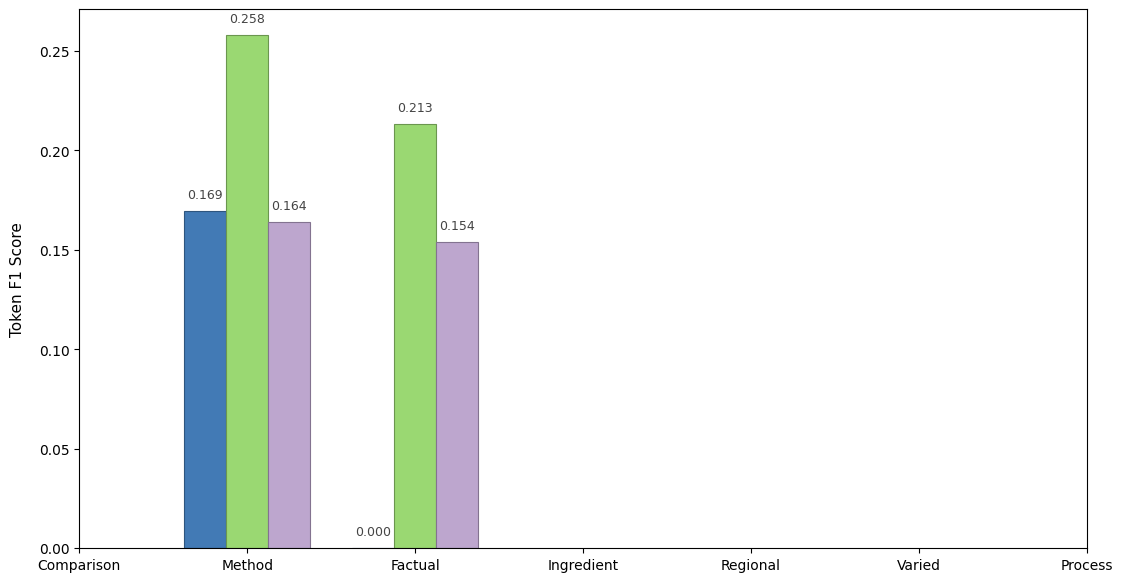

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

custom_palette = ["#427AB5", "#9AD872", "#BDA6CE"]

# Load data
df = pd.read_csv(os.path.join(OUTPUT_DIR, 'prompt_strategy_by_question_type.csv'))

metrics = {
    'token_f1': 'Token F1 Score',
    'rouge_l': 'ROUGE-L Score',
    'bertscore_f1': 'BERTScore F1'
}

question_order = ['comparison', 'method', 'factual', 'ingredient', 'regional', 'varied', 'process']
labels = [q.capitalize() for q in question_order]

for column_name, display_label in metrics.items():
    pivot = df.pivot(index='question_type', columns='prompt_strategy', values=column_name).reindex(question_order)

    zero = pivot['zero_shot_grounded'].values
    few  = pivot['few_shot_grounded'].values
    cot  = pivot['cot_grounded'].values

    x = np.arange(len(labels))
    width = 0.25

    fig, ax = plt.subplots(figsize=(13, 7))

    bars0 = ax.bar(x - width, zero, width, label='Zero-shot', color=custom_palette[0], edgecolor='#2E557E', linewidth=0.8)
    bars1 = ax.bar(x,         few,  width, label='Few-shot',  color=custom_palette[1], edgecolor='#6B964F', linewidth=0.8)
    bars2 = ax.bar(x + width, cot,  width, label='CoT',       color=custom_palette[2], edgecolor='#837390', linewidth=0.8)

    # Highlight CoT winners and stack the star ABOVE the number
    for i, (c, f, z) in enumerate(zip(cot, few, zero)):
        if c > f and c > z:
            bars2[i].set_facecolor('#8F7AA0')
            bars2[i].set_edgecolor('#5A4E63')
            bars2[i].set_linewidth(2)
            # The number is at c + 0.005, so we put the star at c + 0.035
            ax.text(x[i] + width, c + 0.035, '★', ha='center', fontsize=12, color='#5A4E63', fontweight='bold')

    # Value labels
    for bars in [bars0, bars1, bars2]:
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.005,
                    f'{bar.get_height():.3f}',
                    ha='center', va='bottom', fontsize=9, color='#444', fontweight='500')

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_ylabel(display_label, fontsize=11, labelpad=10)

    # Increased multiplier to 1.3 for maximum headroom
    max_val = max(cot.max(), few.max(), zero.max())
    ax.set_ylim(0, max_val * 1.3)

    ax.set_title(f'Prompting Strategy Performance: {display_label} by Question Type',
                 fontsize=14, fontweight='bold', pad=40)

    ax.legend(fontsize=10, frameon=False, loc='upper left', bbox_to_anchor=(0, 1.05), ncol=3)
    ax.yaxis.grid(True, linestyle='--', alpha=0.3, color='#999')
    ax.set_axisbelow(True)

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    plt.tight_layout()
    plt.subplots_adjust(top=0.85) # Pushes the whole graph down slightly

    plt.savefig(os.path.join(OUTPUT_DIR, f'performance_{column_name}.png'), dpi=300, bbox_inches='tight')
    plt.show()


# 8. System orchestration

This part connects the individual components into a runnable end-to-end workflow.


## 8.1 Input route A: upload JSON input

Use this route when the system should consume a prepared JSON input file.

In [9]:
# Run the cell, upload input_payload.json, and the notebook will save output_payload.json.
import json
import ipywidgets as widgets
from IPython.display import display, clear_output
from tqdm import tqdm

OUTPUT_PATH = "output_payload.json"

upload_widget = widgets.FileUpload(
    accept=".json",
    multiple=False,
    description="Upload JSON"
)

run_button = widgets.Button(
    description="Run Inference",
    button_style="success"
)

output_log = widgets.Output()

def on_run_clicked(b):
    with output_log:
        clear_output()

        if not upload_widget.value:
            print("No file uploaded. Please upload a JSON file first.")
            return

        # Read uploaded file
        uploaded_file = list(upload_widget.value.values())[0]
        raw_bytes = uploaded_file["content"]
        payload = json.loads(raw_bytes.decode("utf-8"))

        queries = payload.get("queries", [])
        print(f"Loaded {len(queries)} queries from uploaded file.")

        results = []

        for item in tqdm(queries, desc="Running inference"):
            query_id   = str(item.get("query_id", ""))
            query_text = item.get("query", "")

            result = generate_answer(
                query=query_text,
                top_k=5,
                reranker="cross_encoder",
                prompt_strategy="cot_grounded"
            )

            answer = result.get("answer", "I don't know based on the retrieved context.")

            results.append({
                "query_id": query_id,
                "query": query_text,
                "response": answer,
                "retrieved_context": [
                    {
                        "doc_id": str(chunk.get("chunk_id", i)),
                        "text": chunk.get("text", "")
                    }
                    for i, chunk in enumerate(result.get("retrieved_chunks", []))
                ]
            })

        output_payload = {"results": results}

        with open(OUTPUT_PATH, "w", encoding="utf-8") as f:
            json.dump(output_payload, f, ensure_ascii=False, indent=2)

        print(f"\nDone. Saved {len(results)} results to {OUTPUT_PATH}")
        for r in results[:2]:
            print(f"  [{r['query_id']}] {r['response'][:100]}...")

run_button.on_click(on_run_clicked)

display(upload_widget, run_button, output_log)

FileUpload(value={}, accept='.json', description='Upload JSON')

Button(button_style='success', description='Run Inference', style=ButtonStyle())

Output()

## 8.2 Input route B: plain text input

Use this route when interacting with the system in a simpler chatbot-style mode, where the user enters a query directly as plain text.


In [10]:
import json
import ipywidgets as widgets
from IPython.display import display, clear_output

OUTPUT_PATH = "output_payload.json"

question_widget = widgets.Textarea(
    placeholder="Type your question here e.g. What is biryani?",
    description="Question:",
    layout=widgets.Layout(width="100%", height="80px")
)

ask_button = widgets.Button(
    description="Ask",
    button_style="success"
)

clear_button = widgets.Button(
    description="Clear",
    button_style="warning"
)

status_widget = widgets.HTML(value="")

output_log = widgets.Output()

# Keep track of all questions and answers in the session
session_results = []

def on_ask_clicked(b):
    query_text = question_widget.value.strip()

    if not query_text:
        status_widget.value = "<b style='color:red;'> Please type a question first.</b>"
        return

    ask_button.disabled = True
    ask_button.description = "Thinking..."
    status_widget.value = """
        <div style='
            padding: 10px;
            background: #fff3cd;
            border-left: 4px solid #ffc107;
            border-radius: 4px;
            font-size: 10px;
        '>
             <b>Processing your question...</b><br>
        </div>
    """

    with output_log:
        print(f"Q: {query_text}")

    try:
        result = generate_answer(
            query=query_text,
            top_k=5,
            reranker="cross_encoder",
            prompt_strategy="cot_grounded"
        )

        answer = result.get("answer", "I don't know based on the retrieved context.")

        with output_log:
            print(f"\n{answer}")
            print("-" * 60)

        # Save to session
        query_id = str(len(session_results))
        session_results.append({
            "query_id": query_id,
            "query": query_text,
            "response": answer,
            "retrieved_context": [
                {
                    "doc_id": str(chunk.get("chunk_id", i)),
                    "text": chunk.get("text", "")
                }
                for i, chunk in enumerate(result.get("retrieved_chunks", []))
            ]
        })

        output_payload = {"results": session_results}
        with open(OUTPUT_PATH, "w", encoding="utf-8") as f:
            json.dump(output_payload, f, ensure_ascii=False, indent=2)

        # Clear input box ready for next question
        question_widget.value = ""

        status_widget.value = f"""
            <div style='
                padding: 10px;
                background: #d4edda;
                border-left: 4px solid #28a745;
                border-radius: 4px;
                font-size: 10px;
            '>
                 <b>Answer generated.</b> Total questions asked this session: {len(session_results)}
            </div>
        """

    except Exception as e:
        with output_log:
            print(f"Error: {str(e)}")
        status_widget.value = f"<b style='color:red;'> Error: {str(e)}</b>"

    finally:
        ask_button.disabled = False
        ask_button.description = "Ask"


def on_clear_clicked(b):
    with output_log:
        clear_output()
    session_results.clear()
    question_widget.value = ""
    status_widget.value = "<b style='color:gray;'> Session cleared.</b>"

ask_button.on_click(on_ask_clicked)
clear_button.on_click(on_clear_clicked)

display(
    question_widget,
    widgets.HBox([ask_button, clear_button]),
    status_widget,
    output_log
)

Textarea(value='', description='Question:', layout=Layout(height='80px', width='100%'), placeholder='Type your…

HTML(value='')

Output()

# 9. Final user interface

This final section exposes the complete RAG workflow through a Gradio interface so the system can be demonstrated interactively.



In [11]:
# This cell launches the final Gradio interface for the RAG system.
# !pip install -q gradio
# !pip install --upgrade gradio

import gradio as gr
import json

def run_query(query, top_k=5, reranker="cross_encoder", prompt_strategy="few_shot_grounded"):
    top_k = min(top_k, 5)

    result = generate_answer(query, top_k=top_k, reranker=reranker, prompt_strategy=prompt_strategy)

    if result["status"] != "success":
        return "I don't know.", []

    answer = result["answer"]
    retrieved_chunks = result["retrieved_chunks"]

    context_display = []
    for chunk in retrieved_chunks:
        context_display.append({
            "chunk_id": str(chunk["chunk_id"]),
            "source": chunk.get("source", ""),
            "title": chunk.get("source_title", ""),
            "text": chunk["text"][:500] + ("..." if len(chunk["text"]) > 500 else "")
            # "score": chunk.get("final_score", None)
        })
    return answer, context_display

# batch processing
def process_batch(file_input, json_text, top_k, reranker, progress=gr.Progress()):
    try:
        # Enforce at most 5 chunks
        top_k = min(top_k, 5)

        if file_input is not None and file_input != "":
            import os
            if not os.path.exists(file_input) or os.path.getsize(file_input) == 0:
                return None, "Error: Uploaded file is empty or does not exist.", None
            with open(file_input, "r", encoding="utf-8") as f:
                data = json.load(f)
        elif json_text.strip():
            data = json.loads(json_text)
        else:
            return None, "Error: Please either upload a JSON file or paste JSON content.", None

        if isinstance(data, list):
            queries = data
        elif isinstance(data, dict) and "queries" in data:
            queries = data["queries"]
        else:
            return None, "Error: Input JSON must be a list or contain a 'queries' key.", None

        if not queries:
            return None, "Error: No queries found in input.", None

        results = []
        total = len(queries)
        for idx, q in enumerate(queries):
            progress((idx+1)/total, desc=f"Processing query {idx+1}/{total}")
            qid = q.get("query_id", "")
            query_text = q.get("query", "")
            if not query_text:
                continue


            result = generate_answer(query_text, top_k=top_k, reranker=reranker, prompt_strategy="few_shot_grounded")

            if result["status"] == "success":
                answer = result["answer"]
                retrieved_chunks = result["retrieved_chunks"]
                retrieved_context = [
                    {
                        "doc_id": str(chunk.get("chunk_id", "")),
                        "text": chunk.get("text", "")
                    }
                    for chunk in retrieved_chunks
                ]
            else:
                answer = "I don't know."
                retrieved_context = []

            results.append({
                "query_id": qid,
                "query": query_text,
                "response": answer,
                "retrieved_context": retrieved_context
            })

        output = {"results": results}
        out_path = "output.json"
        with open(out_path, "w") as f:
            json.dump(output, f, indent=2)

        return out_path, f"Successfully processed {len(results)} queries.", output
    except json.JSONDecodeError as e:
        return None, f"Error: Invalid JSON format. {e.msg} at position {e.pos}.", None
    except Exception as e:
        return None, f"Error: {str(e)}", None

def clear_interactive():
    return "", "", []


with gr.Blocks(title="South Asian Cuisine RAG Assistant", theme=gr.themes.Soft()) as demo:
    gr.Markdown("""
    # 🍛 South Asian Cuisine RAG Assistant
    This system uses:
    - **Adaptive chunking** (source‑aware)
    - **BGE embeddings** (`BAAI/bge-large-en-v1.5`) for dense retrieval
    - **Hybrid retrieval** (dense + BM25)
    - **Cross‑encoder reranking** for relevance
    - **Chain of Thoughts prompting** (best performing) for generation
    """)


    with gr.Tab("Interactive"):
        with gr.Row():
            with gr.Column(scale=2):
                query_input = gr.Textbox(
                    label="Your Question",
                    placeholder="e.g., What is the difference between dosa and idli batter?",
                    lines=2
                )
                with gr.Row():
                    reranker_choice = gr.Dropdown(
                        choices=["cross_encoder", "similarity", "mmr"],
                        value="cross_encoder",
                        label="Reranker",
                        info="cross_encoder = most accurate (slower), similarity = fast, mmr = balances relevance & diversity"
                    )
                    top_k_slider = gr.Slider(
                        minimum=1, maximum=5, value=5, step=1,
                        label="Top‑K Chunks"
                    )
                # Radio buttons for prompt strategy
                prompt_strategy_radio = gr.Radio(
                    choices=[
                        ("Zero‑shot", "zero_shot_grounded"),
                        ("Few‑shot", "few_shot_grounded"),
                        ("Chain‑of‑Thought", "cot_grounded")
                    ],
                    value="cot_grounded",
                    label="Prompting Strategy",
                )
                with gr.Row():
                    submit_btn = gr.Button("Get Answer", variant="primary")
                    clear_btn = gr.Button("Clear", variant="secondary")
            with gr.Column(scale=3):
                answer_output = gr.Textbox(label="Answer", lines=8)
                with gr.Accordion("Retrieved Chunks", open=True):
                    chunks_display = gr.JSON(label="Chunks")

        submit_btn.click(
            fn=run_query,
            inputs=[query_input, top_k_slider, reranker_choice, prompt_strategy_radio],
            outputs=[answer_output, chunks_display]
        )
        clear_btn.click(
            fn=clear_interactive,
            inputs=[],
            outputs=[query_input, answer_output, chunks_display]
        )

    with gr.Tab("Batch Processing"):
        gr.Markdown("### Option 1: Upload a JSON file")
        gr.Markdown("The file should contain a list of queries under the key `\"queries\"`, or be a list directly.")
        gr.Code('''{
  "queries": [
    {"query_id": "0", "query": "What is the main difference between dosa and idli batter?"},
    {"query_id": "1", "query": "How is biryani traditionally cooked and what are its key ingredients?"}
  ]
}''', language="json")

        file_input = gr.File(label="Upload JSON file", file_types=[".json"], type="filepath")

        gr.Markdown("### Option 2: Paste JSON directly")
        json_textbox = gr.Textbox(
            label="Paste JSON here",
            placeholder='{"queries": [{"query_id": "0", "query": "What is dosa?"}]}',
            lines=6
        )

        with gr.Row():
            batch_reranker = gr.Dropdown(
                choices=["cross_encoder", "similarity", "mmr"],
                value="cross_encoder",
                label="Reranker"
            )
            batch_top_k = gr.Slider(
                minimum=1, maximum=5, value=5, step=1,
                label="Top‑K Chunks"
            )

        process_btn = gr.Button("Process Queries", variant="primary")
        output_file = gr.File(label="Download Output")
        status = gr.Textbox(label="Status")
        output_preview = gr.JSON(label="Output Preview (with retrieved context)")

        process_btn.click(
            fn=process_batch,
            inputs=[file_input, json_textbox, batch_top_k, batch_reranker],
            outputs=[output_file, status, output_preview]
        )

demo.launch(share=True)

/tmp/ipykernel_10980/341254353.py:105: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(title="South Asian Cuisine RAG Assistant", theme=gr.themes.Soft()) as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d4875bfa32b862c4a3.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
